# Data Validation
Pre-modeling sanity checks on `dataset.parquet`.

Sections:
1. Load & overview
2. NaN audit
   - 2b. Baseline extraction helper (per-cell calibration)
   - 2c. CNR mean-norm vs median-norm comparison
   - 2d. OptoRTK expression (optocheck) visualisation
3. Signal quality (ERK response)
   - 3b. Trajectory diversity (spaghetti plots)
   - Non-responder detection (dual-criterion: per-cell SNR + variance ratio)
   - Response characterisation (6-feature phenotype vector)
4. Stimulus-response alignment (fixed cross-correlation + per-cell peak lag)
5. Engineered feature sanity
6. Per-cell outlier detection + baseline drift check
7. Cross-experiment comparability
8. Class balance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import sys
from pathlib import Path
from scipy.signal import correlate

sys.path.insert(0, str(Path('..').resolve()))
from notebooks.experiment.preprocessing import plot_nan_audit

PARQUET = Path('./dataset.parquet')
df = pd.read_parquet(PARQUET)

# Compatibility: older datasets use 'cnr_norm', newer use 'cnr_mean_norm'
if 'cnr_norm' in df.columns and 'cnr_mean_norm' not in df.columns:
    df.rename(columns={'cnr_norm': 'cnr_mean_norm'}, inplace=True)

patterns = sorted(df['ramp_pattern_name'].unique())
print(f"{len(df):,} rows  |  {df['uid'].nunique():,} cells  |  {len(patterns)} experiments")
df['ramp_pattern_name'].value_counts()

274,674 rows  |  1,953 cells  |  4 experiments


ramp_pattern_name
3-2-1minIntervals    141016
Sustained             89613
ramp1                 29329
Single                14716
Name: count, dtype: int64

## 1. Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274674 entries, 0 to 274673
Data columns (total 54 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   mean_intensity_C0_nuc             274674 non-null  float64
 1   mean_intensity_C1_nuc             274674 non-null  float64
 2   label                             274674 non-null  uint32 
 3   x                                 274674 non-null  float64
 4   y                                 274674 non-null  float64
 5   area                              274674 non-null  float64
 6   median_intensity_C0_nuc           274674 non-null  float64
 7   median_intensity_C1_nuc           274674 non-null  float64
 8   mean_intensity_C0_ring            274674 non-null  float64
 9   mean_intensity_C1_ring            274674 non-null  float64
 10  median_intensity_C0_ring          274674 non-null  float64
 11  median_intensity_C1_ring          274674 non-null  f

## 2. NaN audit

No NaN values found in any column — data is clean.


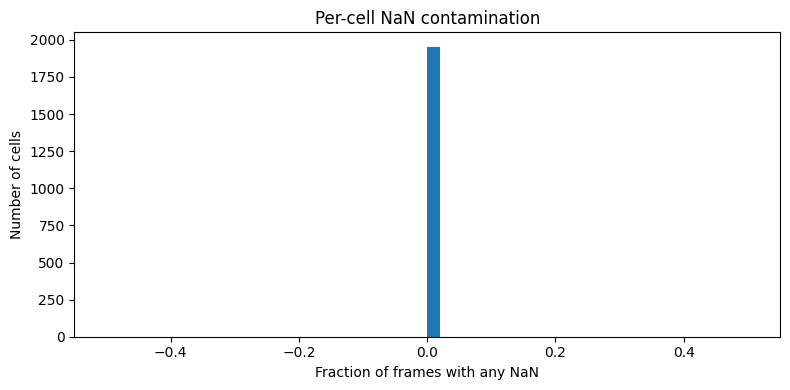

Cells with >10% NaN frames: 0 / 1953


In [5]:
cell_nan_frac = plot_nan_audit(df)

## 2b. Baseline extraction helper

Every per-cell metric is calibrated against that cell's own baseline (frames 0–9), not the population.
This sidesteps pooling between-cell and between-experiment variance and naturally accounts for
differences in reporter expression, segmentation quality, and baseline CNR.

In [6]:
BASELINE_FRAMES = 10  # frames 0–9

def extract_baseline(grp):
    """Return baseline_mean, baseline_std, first_stim_frame for one cell."""
    grp = grp.sort_values('frame')
    bl = grp.iloc[:BASELINE_FRAMES]
    return pd.Series({
        'baseline_mean': bl['cnr_median_norm'].mean(),
        'baseline_std': bl['cnr_median_norm'].std(),
        'baseline_mean_raw': bl['cnr_mean_norm'].mean(),
        'baseline_std_raw': bl['cnr_mean_norm'].std(),
        'first_stim_frame': grp.loc[grp['stim_exposure'] > 0, 'frame'].min()
            if (grp['stim_exposure'] > 0).any() else np.nan,
    })

cell_baseline = df.groupby('uid', observed=True).apply(extract_baseline).reset_index()
cell_baseline = cell_baseline.merge(
    df.groupby('uid')['ramp_pattern_name'].first().reset_index(), on='uid'
)

# Verify baseline frames are pre-stim
bl_check = df[df['frame'] < BASELINE_FRAMES]
assert (bl_check['stim_exposure'] == 0).all(), "ERROR: some baseline frames have stim_exposure > 0!"
print(f"Verified: all {BASELINE_FRAMES} baseline frames have stim_exposure == 0 across all experiments.")
print(f"Baseline extracted for {len(cell_baseline)} cells.")

Verified: all 10 baseline frames have stim_exposure == 0 across all experiments.
Baseline extracted for 1953 cells.


/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_74513/3660684335.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_baseline = df.groupby('uid', observed=True).apply(extract_baseline).reset_index()


## 2c. CNR mean-norm vs median-norm comparison

Both `cnr_mean_norm` (mean ring/nuc, baseline-normalised) and `cnr_median_norm` (median ring/nuc, baseline-normalised)
are computed. The median variant is more robust to segmentation artefacts and intensity outliers,
but the mean variant may capture subtle changes better in clean cells.
Below we check how well they agree and where they diverge.

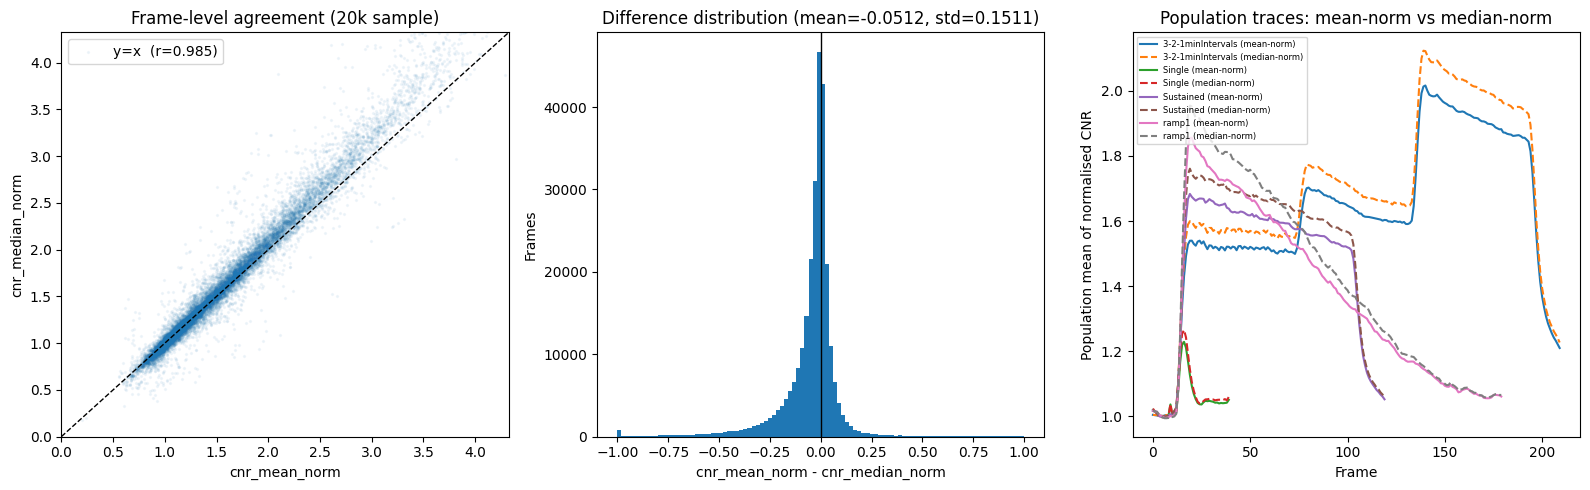

Cells with high mean/median divergence (std > 0.1): 273 / 1953
Mean divergence std across cells: 0.0574


/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_74513/1346028042.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_divergence = df.groupby('uid').apply(


In [7]:
# --- Per-frame agreement ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: frame-level agreement
ax = axes[0]
sample = df.sample(n=min(20_000, len(df)), random_state=0)
ax.scatter(sample['cnr_mean_norm'], sample['cnr_median_norm'], alpha=0.05, s=2)
lims = [0, sample[['cnr_mean_norm', 'cnr_median_norm']].quantile(0.99).max()]
ax.plot(lims, lims, 'k--', lw=1, label='y=x')
ax.set_xlabel('cnr_mean_norm')
ax.set_ylabel('cnr_median_norm')
ax.set_title('Frame-level agreement (20k sample)')
r = sample[['cnr_mean_norm', 'cnr_median_norm']].corr().iloc[0, 1]
ax.legend([f'y=x  (r={r:.3f})'])
ax.set_xlim(lims)
ax.set_ylim(lims)

# Histogram of per-frame difference
ax = axes[1]
diff = df['cnr_mean_norm'] - df['cnr_median_norm']
ax.hist(diff.clip(-1, 1), bins=100, edgecolor='none')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('cnr_mean_norm - cnr_median_norm')
ax.set_ylabel('Frames')
ax.set_title(f'Difference distribution (mean={diff.mean():.4f}, std={diff.std():.4f})')

# Per-experiment population traces comparison
ax = axes[2]
for pat in patterns:
    sub = df[df['ramp_pattern_name'] == pat]
    mean_ts = sub.groupby('frame')['cnr_mean_norm'].mean()
    median_ts = sub.groupby('frame')['cnr_median_norm'].mean()
    ax.plot(mean_ts.index, mean_ts.values, lw=1.5, label=f'{pat} (mean-norm)')
    ax.plot(median_ts.index, median_ts.values, lw=1.5, linestyle='--', label=f'{pat} (median-norm)')
ax.set_xlabel('Frame')
ax.set_ylabel('Population mean of normalised CNR')
ax.set_title('Population traces: mean-norm vs median-norm')
ax.legend(fontsize=6, loc='upper left')

plt.tight_layout()
plt.show()

# Per-cell: which cells show large divergence?
cell_divergence = df.groupby('uid').apply(
    lambda g: (g['cnr_mean_norm'] - g['cnr_median_norm']).std()
).rename('mean_median_divergence')
print(f"Cells with high mean/median divergence (std > 0.1): "
      f"{(cell_divergence > 0.1).sum()} / {len(cell_divergence)}")
print(f"Mean divergence std across cells: {cell_divergence.mean():.4f}")

## 2d. OptoRTK expression (optocheck)

`optocheck_mean_intensity` measures the fluorescence of the optogenetic receptor construct in each cell.
Cells with higher expression have more receptor copies and respond more strongly to the same light dose.
This is a critical confound for modeling: a Low-expression cell receiving identical stimulation
will produce a weaker ERK response than a High-expression cell.

The notebooks in `check_modern_preproc/` split cells into Low/High expression groups via `qcut(q=2)`.
Below we visualise the distribution per experiment and its relationship to response amplitude.

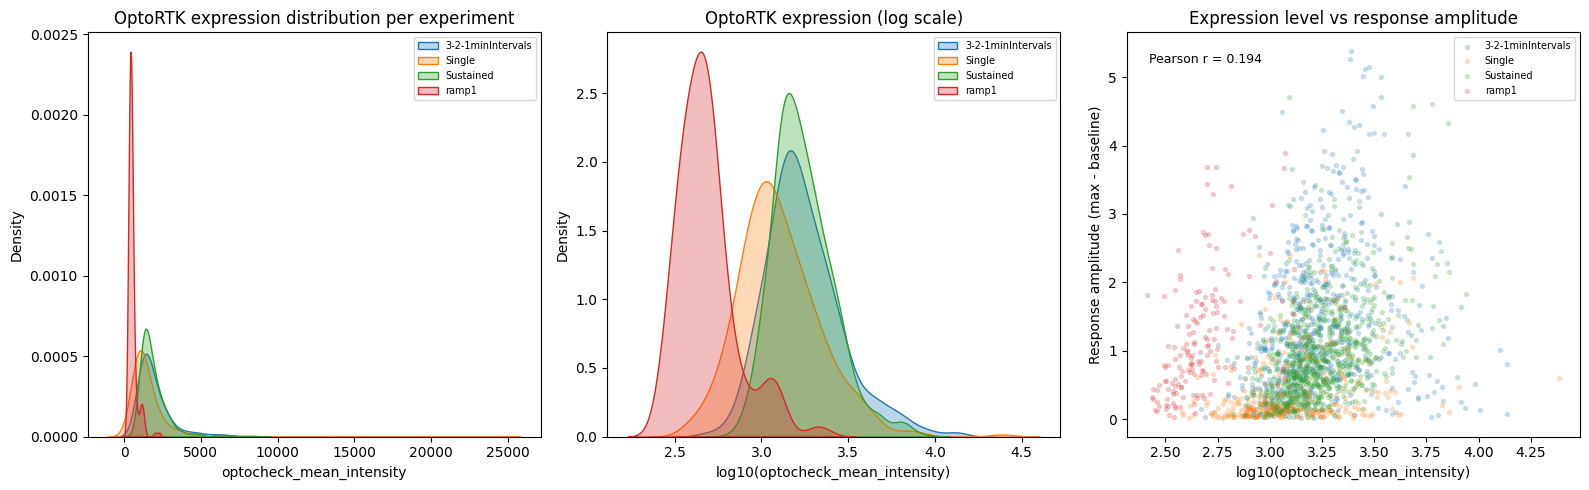

OptoRTK expression summary per experiment:
                   count    mean     std    min     50%      max
ramp_pattern_name                                               
3-2-1minIntervals  672.0  2046.4  1478.1  466.2  1620.0  13701.0
Single             368.0  1524.2  1535.3  377.5  1178.9  24374.6
Sustained          750.0  1905.1   969.9  664.4  1637.1   8718.8
ramp1              163.0   528.1   284.7  258.8   453.0   2271.5


In [8]:
# --- OptoRTK expression distribution ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KDE per experiment
ax = axes[0]
for pat in patterns:
    vals = df[df['ramp_pattern_name'] == pat].groupby('uid')['optocheck_mean_intensity'].first()
    sns.kdeplot(vals, ax=ax, fill=True, alpha=0.3, label=pat)
ax.set_xlabel('optocheck_mean_intensity')
ax.set_ylabel('Density')
ax.set_title('OptoRTK expression distribution per experiment')
ax.legend(fontsize=7)

# Log-scale version (expression often log-normal)
ax = axes[1]
for pat in patterns:
    vals = df[df['ramp_pattern_name'] == pat].groupby('uid')['optocheck_mean_intensity'].first()
    vals_log = np.log10(vals.clip(lower=1))
    sns.kdeplot(vals_log, ax=ax, fill=True, alpha=0.3, label=pat)
ax.set_xlabel('log10(optocheck_mean_intensity)')
ax.set_ylabel('Density')
ax.set_title('OptoRTK expression (log scale)')
ax.legend(fontsize=7)

# Expression vs response amplitude
ax = axes[2]
# Compute per-cell amplitude using cell_baseline
amp_df = df.groupby('uid')['cnr_median_norm'].max().rename('max_cnr').reset_index()
amp_df = amp_df.merge(cell_baseline[['uid', 'baseline_mean', 'ramp_pattern_name']], on='uid')
amp_df['amplitude'] = amp_df['max_cnr'] - amp_df['baseline_mean']
optocheck_per_cell = df.groupby('uid')['optocheck_mean_intensity'].first().reset_index()
amp_df = amp_df.merge(optocheck_per_cell, on='uid')

for pat in patterns:
    sub = amp_df[amp_df['ramp_pattern_name'] == pat]
    ax.scatter(np.log10(sub['optocheck_mean_intensity'].clip(lower=1)),
               sub['amplitude'], alpha=0.2, s=8, label=pat)
ax.set_xlabel('log10(optocheck_mean_intensity)')
ax.set_ylabel('Response amplitude (max - baseline)')
ax.set_title('Expression level vs response amplitude')
ax.legend(fontsize=7)
r = amp_df[['optocheck_mean_intensity', 'amplitude']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}', transform=ax.transAxes, fontsize=9, va='top')

plt.tight_layout()
plt.show()

# Summary stats
opto_stats = amp_df.groupby('ramp_pattern_name')['optocheck_mean_intensity'].describe().round(1)
print("OptoRTK expression summary per experiment:")
print(opto_stats[['count', 'mean', 'std', 'min', '50%', 'max']])

NOTE: Alex mentioned that optocheck results aren't really comparable between experiments. 

## 3. Signal quality (ERK response)

Population-level traces and per-cell trajectory diversity.

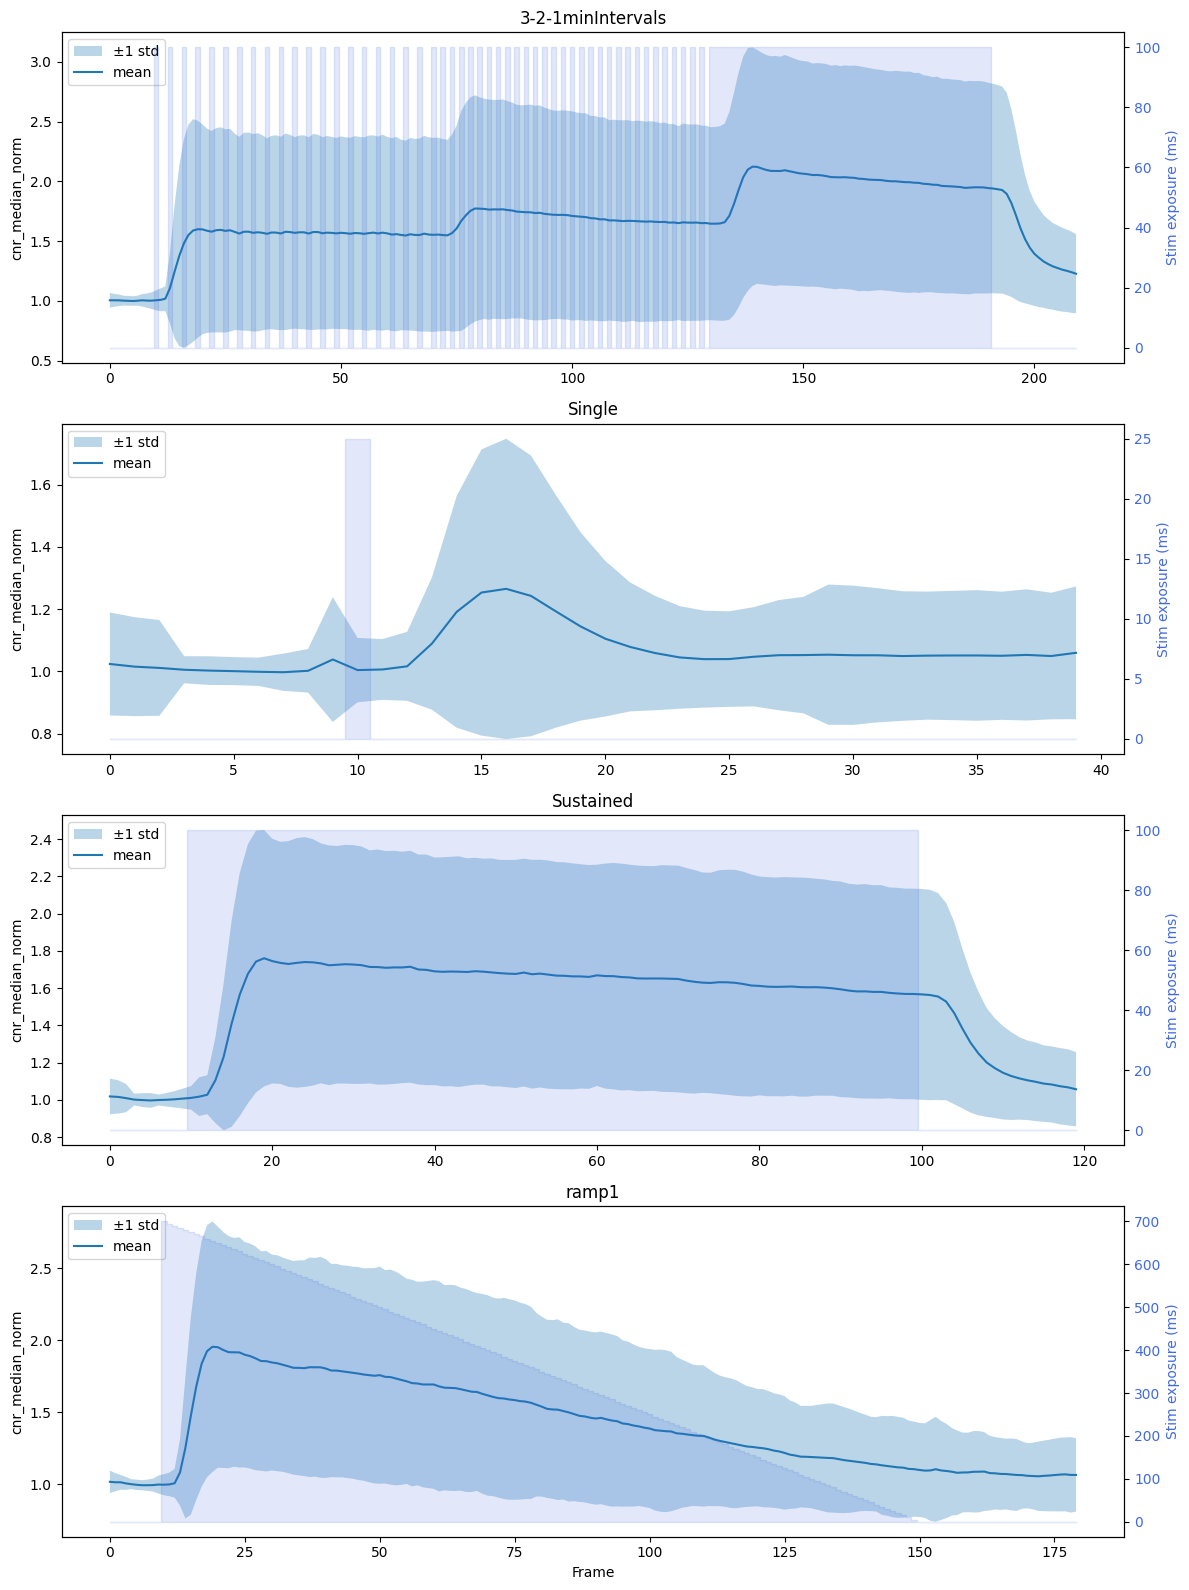

In [9]:
# Population mean ± std of cnr_median_norm vs frame, per experiment
patterns = sorted(df['ramp_pattern_name'].unique())
fig, axes = plt.subplots(len(patterns), 1, figsize=(12, 4 * len(patterns)), sharex=False)
if len(patterns) == 1:
    axes = [axes]

for ax, pat in zip(axes, patterns):
    sub = df[df['ramp_pattern_name'] == pat]
    stats = sub.groupby('frame')['cnr_median_norm'].agg(['mean', 'std'])
    ax.fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                    alpha=0.3, label='±1 std')
    ax.plot(stats.index, stats['mean'], label='mean', lw=1.5)

    stim = sub.groupby('frame')['stim_exposure'].first()
    ax2 = ax.twinx()
    ax2.fill_between(stim.index, stim.values, alpha=0.15, color='royalblue', step='mid')
    ax2.set_ylabel('Stim exposure (ms)', color='royalblue')
    ax2.tick_params(axis='y', labelcolor='royalblue')

    ax.set_title(pat)
    ax.set_ylabel('cnr_median_norm')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Frame')
plt.tight_layout()
plt.show()

### 3b. Trajectory diversity (spaghetti plots)

Individual cell traces overlaid with population median. This is the most informative plot for
motivating autoencoder/latent-space work — it shows the heterogeneity that population averages hide.

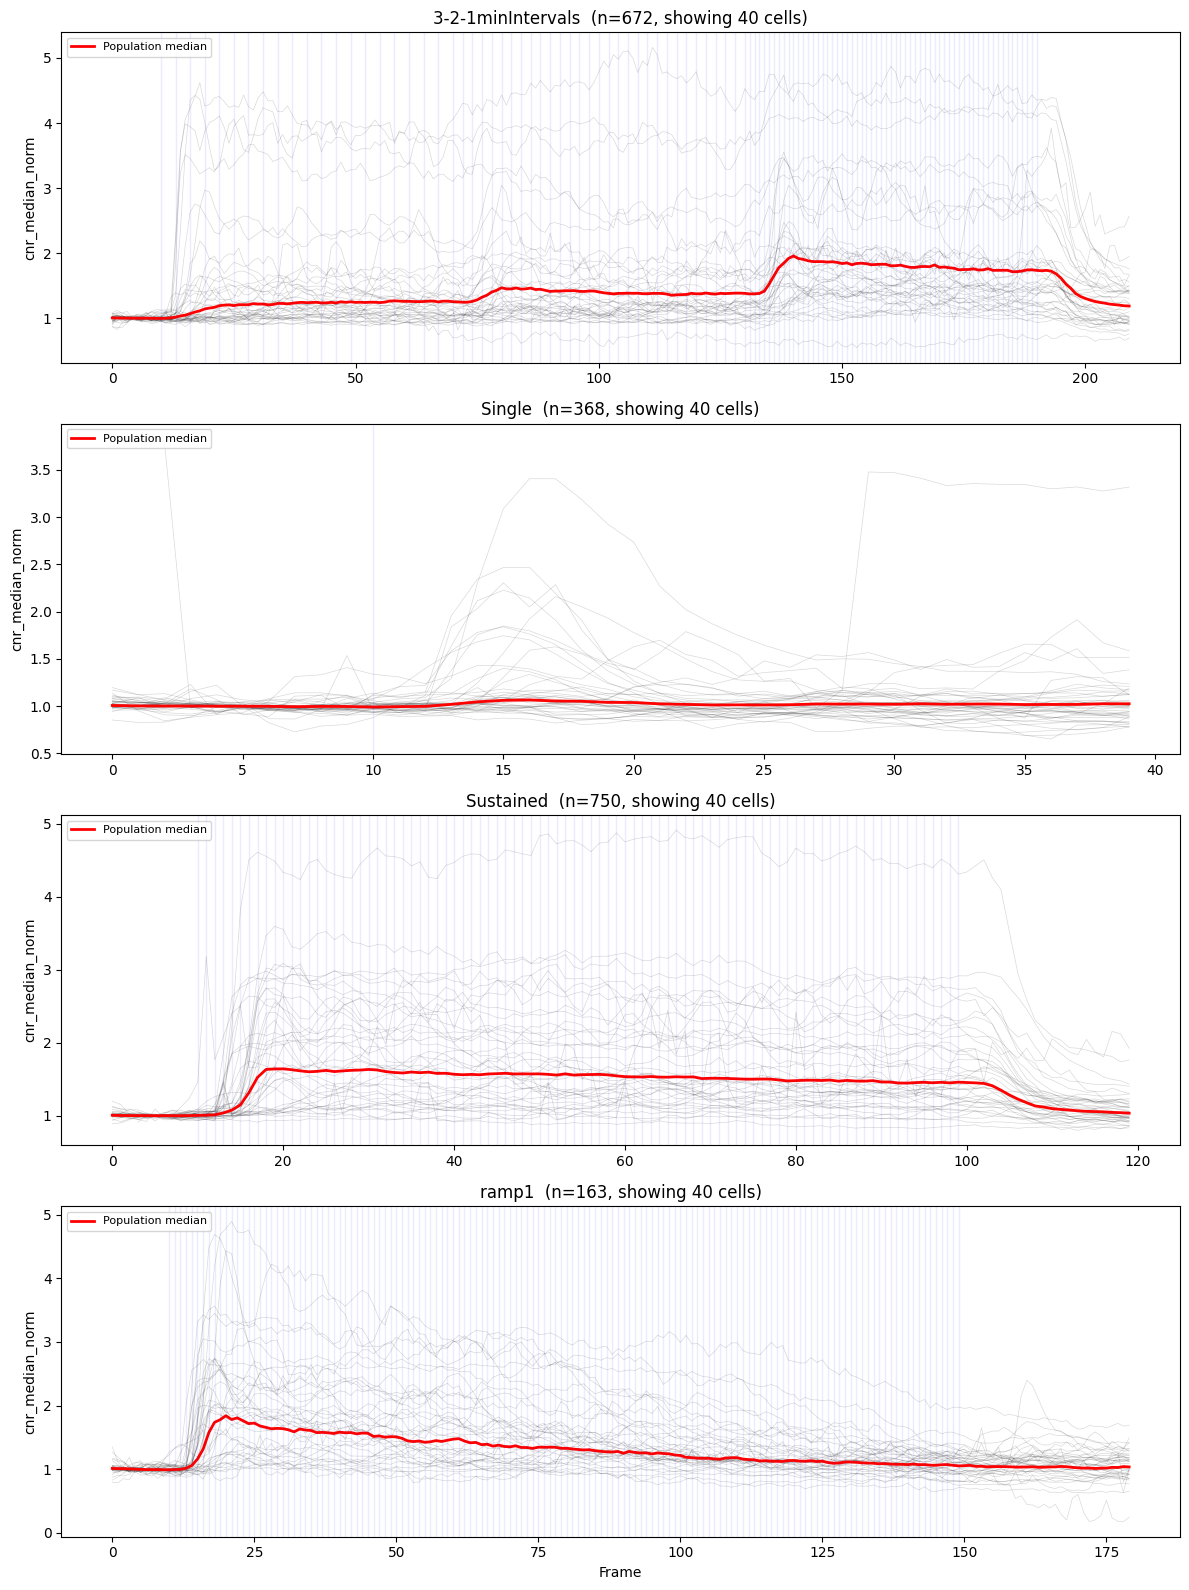

In [10]:
# Spaghetti plot: 40 random cells per experiment, population median in bold
np.random.seed(42)
N_SAMPLE = 40

fig, axes = plt.subplots(len(patterns), 1, figsize=(12, 4 * len(patterns)), sharex=False)
if len(patterns) == 1:
    axes = [axes]

for ax, pat in zip(axes, patterns):
    sub = df[df['ramp_pattern_name'] == pat]
    uids = sub['uid'].unique()
    sampled = np.random.choice(uids, size=min(N_SAMPLE, len(uids)), replace=False)

    for uid in sampled:
        cell = sub[sub['uid'] == uid].sort_values('frame')
        ax.plot(cell['frame'], cell['cnr_median_norm'], color='black', alpha=0.15, lw=0.5)

    pop_median = sub.groupby('frame')['cnr_median_norm'].median()
    ax.plot(pop_median.index, pop_median.values, color='red', lw=2, label='Population median')

    # Stim indicator
    stim = sub.groupby('frame')['stim_exposure'].first()
    stim_frames = stim[stim > 0].index
    for sf in stim_frames:
        ax.axvline(x=sf, color='blue', alpha=0.08, lw=1)

    ax.set_title(f'{pat}  (n={len(uids)}, showing {min(N_SAMPLE, len(uids))} cells)')
    ax.set_ylabel('cnr_median_norm')
    ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('Frame')
plt.tight_layout()
plt.show()

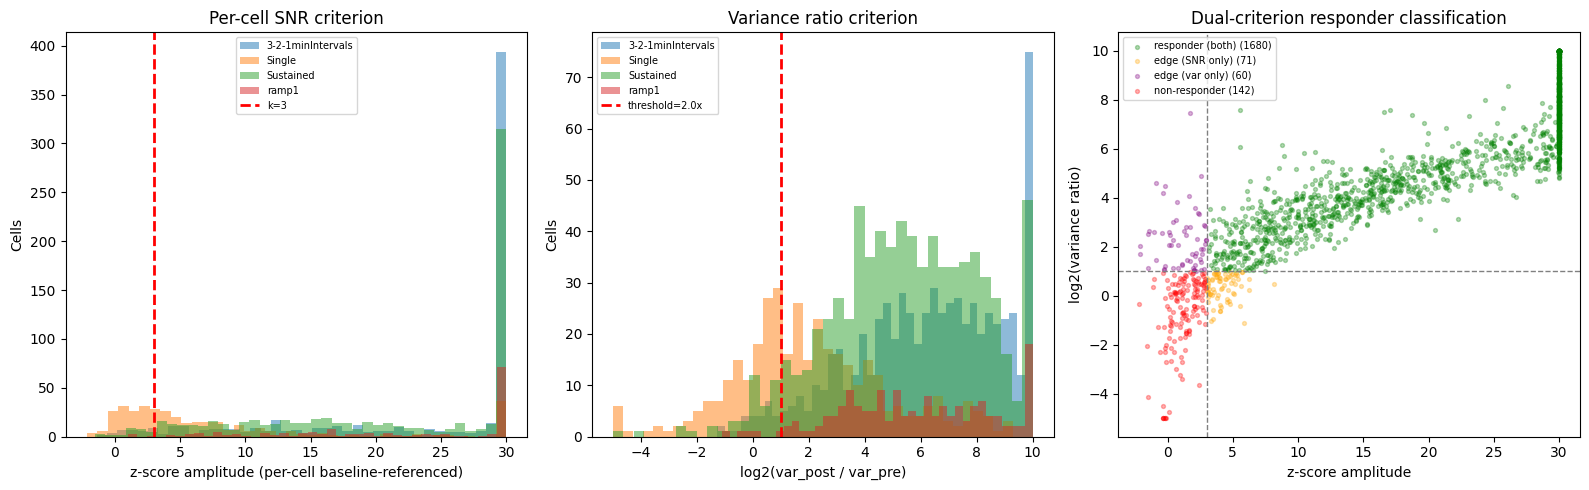


Responder classification per experiment:
category           edge (SNR only)  edge (var only)  non-responder  \
ramp_pattern_name                                                    
3-2-1minIntervals               14               16             13   
Single                          29               33            110   
Sustained                       26                9             17   
ramp1                            2                2              2   

category           responder (both)  
ramp_pattern_name                    
3-2-1minIntervals               629  
Single                          196  
Sustained                       698  
ramp1                           157  

Total: {'responder (both)': 1680, 'non-responder': 142, 'edge (SNR only)': 71, 'edge (var only)': 60}


In [11]:
# --- Dual-criterion non-responder detection ---
# Criterion 1: Per-cell SNR (z-score amplitude)
#   Did the cell's post-stim max exceed baseline_mean + k * baseline_std?
# Criterion 2: Variance ratio
#   Is post-stim variance substantially larger than pre-stim variance?

K_THRESHOLD = 3  # number of cell's own noise std devs
VARIANCE_RATIO_THRESHOLD = 2.0  # post/pre variance ratio
BASELINE_STD_FLOOR = 0.02  # floor for very-low-variance baselines

def compute_responder_criteria(uid):
    cell = df[df['uid'] == uid].sort_values('frame')
    bl = cell.iloc[:BASELINE_FRAMES]['cnr_median_norm']
    post = cell.iloc[BASELINE_FRAMES:]['cnr_median_norm']

    bl_mean = bl.mean()
    bl_std = max(bl.std(), BASELINE_STD_FLOOR)

    # Criterion 1: z-score amplitude
    z_amplitude = (post.max() - bl_mean) / bl_std

    # Criterion 2: variance ratio
    var_pre = bl.var()
    var_post = post.var()
    var_ratio = var_post / max(var_pre, 1e-9)
    log_var_ratio = np.log2(var_ratio) if var_ratio > 0 else 0

    return pd.Series({
        'z_amplitude': z_amplitude,
        'var_ratio': var_ratio,
        'log_var_ratio': log_var_ratio,
        'is_responder_snr': z_amplitude >= K_THRESHOLD,
        'is_responder_var': var_ratio >= VARIANCE_RATIO_THRESHOLD,
    })

resp = pd.DataFrame({uid: compute_responder_criteria(uid) for uid in df['uid'].unique()}).T
resp.index.name = 'uid'
resp = resp.reset_index().merge(
    df.groupby('uid')['ramp_pattern_name'].first().reset_index(), on='uid'
)

# Classification
resp['category'] = 'non-responder'
resp.loc[resp['is_responder_snr'] & resp['is_responder_var'], 'category'] = 'responder (both)'
resp.loc[resp['is_responder_snr'] & ~resp['is_responder_var'], 'category'] = 'edge (SNR only)'
resp.loc[~resp['is_responder_snr'] & resp['is_responder_var'], 'category'] = 'edge (var only)'

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of z-score amplitudes
ax = axes[0]
for pat in patterns:
    vals = resp[resp['ramp_pattern_name'] == pat]['z_amplitude'].clip(-5, 30)
    ax.hist(vals, bins=40, alpha=0.5, label=pat)
ax.axvline(K_THRESHOLD, color='red', lw=2, linestyle='--', label=f'k={K_THRESHOLD}')
ax.set_xlabel('z-score amplitude (per-cell baseline-referenced)')
ax.set_ylabel('Cells')
ax.set_title('Per-cell SNR criterion')
ax.legend(fontsize=7)

# Distribution of log variance ratio
ax = axes[1]
for pat in patterns:
    vals = resp[resp['ramp_pattern_name'] == pat]['log_var_ratio'].clip(-5, 10)
    ax.hist(vals, bins=40, alpha=0.5, label=pat)
ax.axvline(np.log2(VARIANCE_RATIO_THRESHOLD), color='red', lw=2, linestyle='--',
           label=f'threshold={VARIANCE_RATIO_THRESHOLD}x')
ax.set_xlabel('log2(var_post / var_pre)')
ax.set_ylabel('Cells')
ax.set_title('Variance ratio criterion')
ax.legend(fontsize=7)

# Scatter: both criteria
ax = axes[2]
colors = {'responder (both)': 'green', 'edge (SNR only)': 'orange',
          'edge (var only)': 'purple', 'non-responder': 'red'}
for cat, color in colors.items():
    sub = resp[resp['category'] == cat]
    ax.scatter(sub['z_amplitude'].clip(-5, 30), sub['log_var_ratio'].clip(-5, 10),
               alpha=0.3, s=8, c=color, label=f'{cat} ({len(sub)})')
ax.axvline(K_THRESHOLD, color='grey', lw=1, linestyle='--')
ax.axhline(np.log2(VARIANCE_RATIO_THRESHOLD), color='grey', lw=1, linestyle='--')
ax.set_xlabel('z-score amplitude')
ax.set_ylabel('log2(variance ratio)')
ax.set_title('Dual-criterion responder classification')
ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

# Summary table
print("\nResponder classification per experiment:")
print(resp.groupby(['ramp_pattern_name', 'category']).size().unstack(fill_value=0))
print(f"\nTotal: {resp['category'].value_counts().to_dict()}")

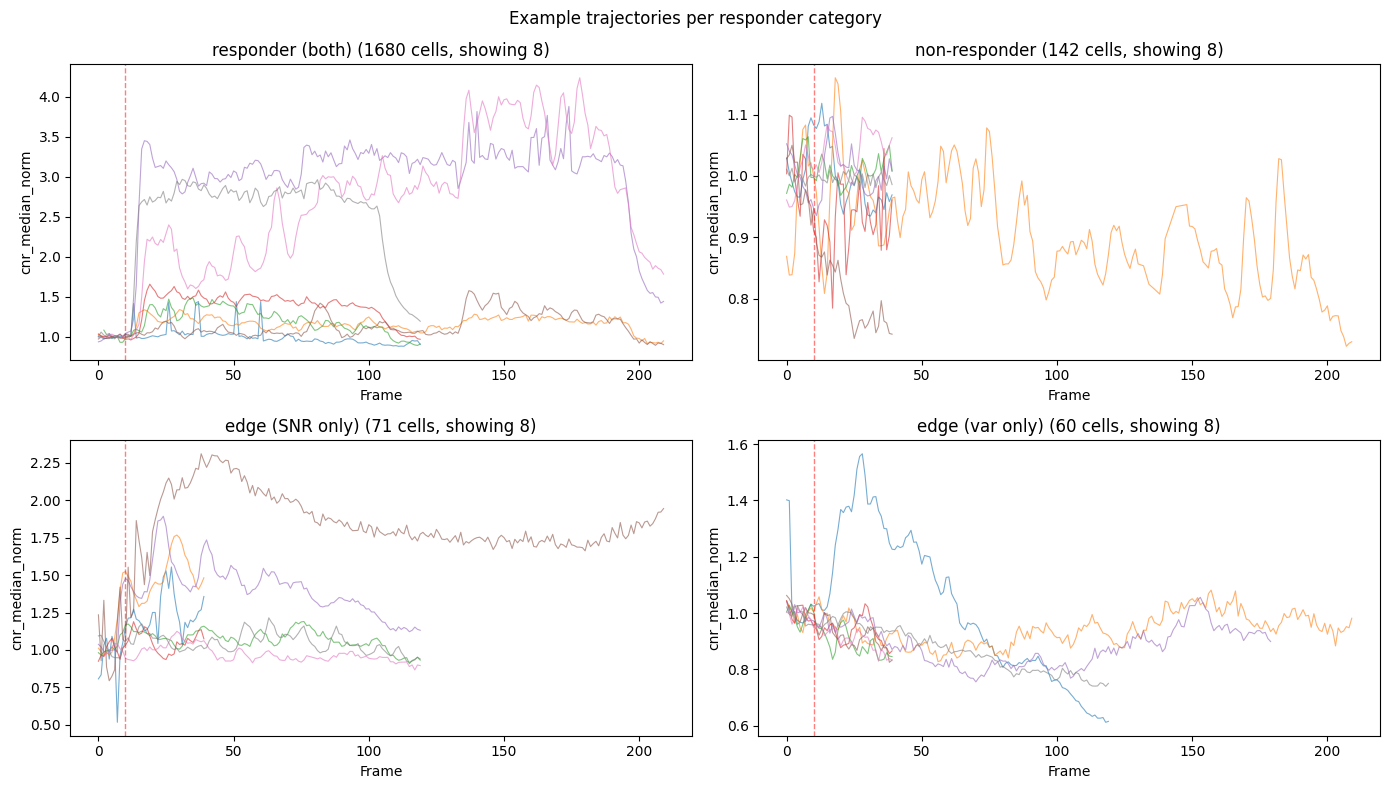

In [12]:
# --- Example trajectories per responder category ---
np.random.seed(7)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
categories = ['responder (both)', 'non-responder', 'edge (SNR only)', 'edge (var only)']

for ax, cat in zip(axes.flat, categories):
    cat_uids = resp[resp['category'] == cat]['uid'].values
    n_show = min(8, len(cat_uids))
    if n_show == 0:
        ax.set_title(f'{cat} (0 cells)')
        continue
    sampled = np.random.choice(cat_uids, size=n_show, replace=False)
    for uid in sampled:
        cell = df[df['uid'] == uid].sort_values('frame')
        ax.plot(cell['frame'], cell['cnr_median_norm'], alpha=0.6, lw=0.8)
    ax.axvline(BASELINE_FRAMES, color='red', lw=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{cat} ({len(cat_uids)} cells, showing {n_show})')
    ax.set_ylabel('cnr_median_norm')
    ax.set_xlabel('Frame')

plt.suptitle('Example trajectories per responder category', fontsize=12)
plt.tight_layout()
plt.show()

### 3c. Response characterisation (phenotype vector)

Six numbers per cell that capture the dimensions of response variation:
1. **Amplitude** -- peak post-stim value minus baseline mean, normalised by baseline std (z-score)
2. **Integrated response** -- area under the curve above baseline in the post-stim window
3. **Time-to-peak** -- frame index of max post-stim value relative to first stimulation
4. **Decay half-life** -- frames from peak to when signal crosses below baseline + 0.5*amplitude
5. **Oscillation score** -- number of zero-crossings (relative to baseline) in post-stim window
6. **Variance ratio** -- var_post / var_pre (also doubles as responder criterion)

In [13]:
def compute_phenotype(uid):
    cell = df[df['uid'] == uid].sort_values('frame')
    bl = cell.iloc[:BASELINE_FRAMES]['cnr_median_norm']
    post = cell.iloc[BASELINE_FRAMES:]['cnr_median_norm']

    bl_mean = bl.mean()
    bl_std = max(bl.std(), BASELINE_STD_FLOOR)

    # 1. Amplitude (z-score)
    peak_val = post.max()
    amplitude = (peak_val - bl_mean) / bl_std

    # 2. Integrated response (AUC above baseline)
    above_bl = (post - bl_mean).clip(lower=0)
    integrated = above_bl.sum()  # each frame = 1 min, so sum = AUC in min*units

    # 3. Time-to-peak (relative to stim onset)
    time_to_peak = post.idxmax() - post.index[0] if len(post) > 0 else np.nan
    # Convert from index to frame offset
    peak_frame = cell.loc[post.idxmax(), 'frame'] if len(post) > 0 else np.nan
    ttp = peak_frame - BASELINE_FRAMES if not np.isnan(peak_frame) else np.nan

    # 4. Decay half-life: frames from peak to when signal drops below baseline + 0.5*amp
    raw_amp = peak_val - bl_mean
    half_level = bl_mean + 0.5 * raw_amp
    post_peak = post.loc[post.idxmax():]
    crossings = post_peak[post_peak < half_level]
    if len(crossings) > 0 and len(post) > 0:
        decay_half = cell.loc[crossings.index[0], 'frame'] - peak_frame
    else:
        decay_half = np.nan  # never decayed to half

    # 5. Oscillation score: zero-crossings relative to baseline
    centered = (post - bl_mean).values
    sign_changes = np.diff(np.sign(centered))
    osc_score = np.count_nonzero(sign_changes)

    # 6. Variance ratio
    var_ratio = post.var() / max(bl.var(), 1e-9)

    return pd.Series({
        'amplitude_z': amplitude,
        'integrated_response': integrated,
        'time_to_peak': ttp,
        'decay_half_life': decay_half,
        'oscillation_score': osc_score,
        'variance_ratio': var_ratio,
    })

phenotype = pd.DataFrame({uid: compute_phenotype(uid) for uid in df['uid'].unique()}).T
phenotype.index.name = 'uid'
phenotype = phenotype.reset_index().merge(
    df.groupby('uid')['ramp_pattern_name'].first().reset_index(), on='uid'
)

print(f"Phenotype features computed for {len(phenotype)} cells.")
phenotype.describe().round(2)

Phenotype features computed for 1953 cells.


,amplitude_z,integrated_response,time_to_peak,decay_half_life,oscillation_score,variance_ratio
count,1953.00,1953.00,1953.00,1818.00,1953.00,1953.00
mean,34.60,80.67,56.23,31.67,3.99,242.20
std,37.39,110.23,56.74,35.04,5.77,752.92
min,-2.16,0.00,0.00,0.00,0.00,0.00
25%,8.70,8.75,9.00,4.00,1.00,7.85
50%,22.21,43.94,27.00,17.00,2.00,38.42
75%,47.92,103.23,127.00,53.00,5.00,185.91
max,263.49,827.40,198.00,184.00,50.00,14350.75


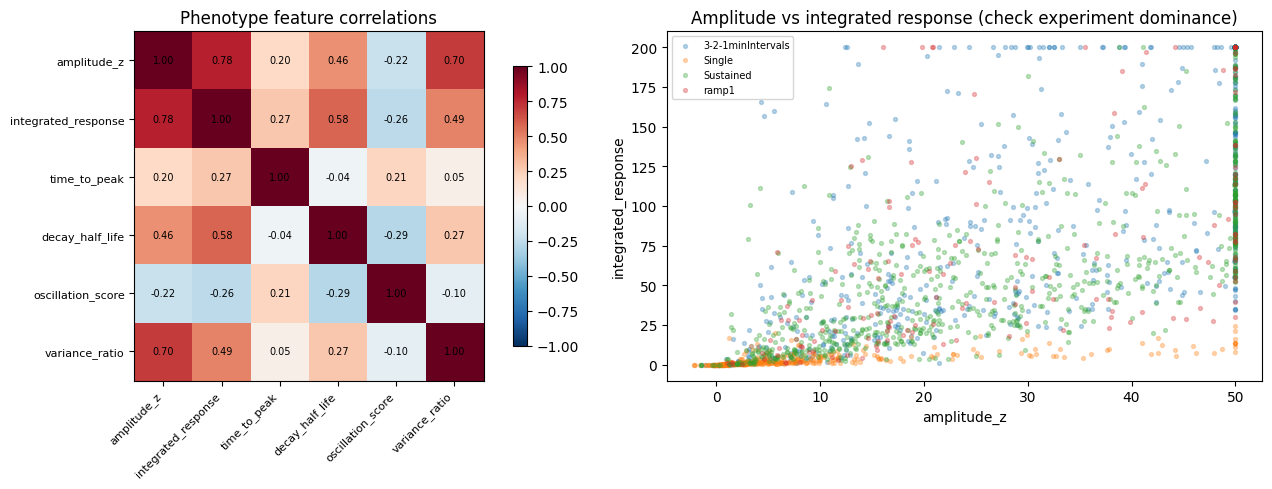

No feature pairs with |r| > 0.9 — all carry independent information.


In [14]:
# Phenotype feature correlation matrix + pairwise scatter by experiment
feat_cols = ['amplitude_z', 'integrated_response', 'time_to_peak',
             'decay_half_life', 'oscillation_score', 'variance_ratio']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
ax = axes[0]
corr = phenotype[feat_cols].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols)))
ax.set_yticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feat_cols, fontsize=8)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Phenotype feature correlations')

# Key scatter: amplitude vs integrated response, colored by experiment
ax = axes[1]
for pat in patterns:
    sub = phenotype[phenotype['ramp_pattern_name'] == pat]
    ax.scatter(sub['amplitude_z'].clip(-5, 50), sub['integrated_response'].clip(-5, 200),
               alpha=0.3, s=8, label=pat)
ax.set_xlabel('amplitude_z')
ax.set_ylabel('integrated_response')
ax.set_title('Amplitude vs integrated response (check experiment dominance)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        r = abs(corr.iloc[i, j])
        if r > 0.9:
            high_corr.append(f"  {feat_cols[i]} <-> {feat_cols[j]}: r={corr.iloc[i,j]:.3f}")
if high_corr:
    print("Highly correlated pairs (|r| > 0.9) — consider dropping one:")
    print('\n'.join(high_corr))
else:
    print("No feature pairs with |r| > 0.9 — all carry independent information.")

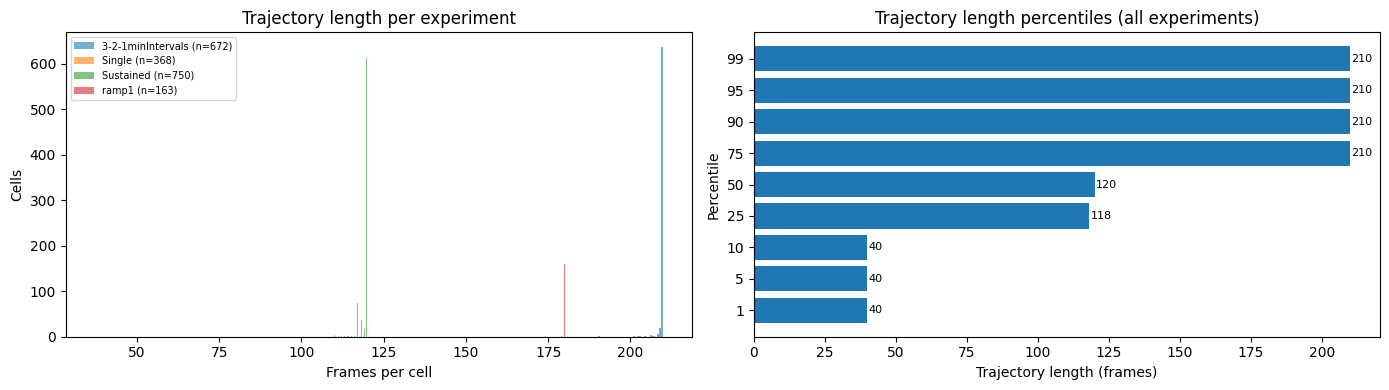

5th percentile trajectory length: 40 frames
Trajectory length decision: cells shorter than 40 frames should be excluded or padded.
  - Excluded: 2 cells (0.1%)
  - Per experiment:
    3-2-1minIntervals: 672 cells, range [190, 210]
    Single: 368 cells, range [37, 40]
    Sustained: 750 cells, range [110, 120]
    ramp1: 163 cells, range [174, 180]


In [15]:
# Trajectory length consistency + decision
traj_len = df.groupby(['uid', 'ramp_pattern_name'], observed=True)['frame'].count().reset_index()
traj_len.columns = ['uid', 'ramp_pattern_name', 'n_frames']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for pat in patterns:
    vals = traj_len[traj_len['ramp_pattern_name'] == pat]['n_frames']
    ax.hist(vals, bins=30, alpha=0.6, label=f"{pat} (n={len(vals)})")
ax.set_xlabel('Frames per cell')
ax.set_ylabel('Cells')
ax.set_title('Trajectory length per experiment')
ax.legend(fontsize=7)

# Percentiles
ax = axes[1]
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = traj_len['n_frames'].quantile([p/100 for p in pcts])
ax.barh([str(p) for p in pcts], pct_vals.values)
ax.set_xlabel('Trajectory length (frames)')
ax.set_ylabel('Percentile')
ax.set_title('Trajectory length percentiles (all experiments)')
for i, v in enumerate(pct_vals.values):
    ax.text(v + 0.5, i, f'{int(v)}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

p5 = int(traj_len['n_frames'].quantile(0.05))
print(f"5th percentile trajectory length: {p5} frames")
print(f"Trajectory length decision: cells shorter than {p5} frames should be excluded or padded.")
print(f"  - Excluded: {(traj_len['n_frames'] < p5).sum()} cells ({(traj_len['n_frames'] < p5).mean()*100:.1f}%)")
print(f"  - Per experiment:")
for pat in patterns:
    sub = traj_len[traj_len['ramp_pattern_name'] == pat]
    max_len = sub['n_frames'].max()
    min_len = sub['n_frames'].min()
    print(f"    {pat}: {len(sub)} cells, range [{min_len}, {max_len}]")

## 4. Stimulus–response alignment

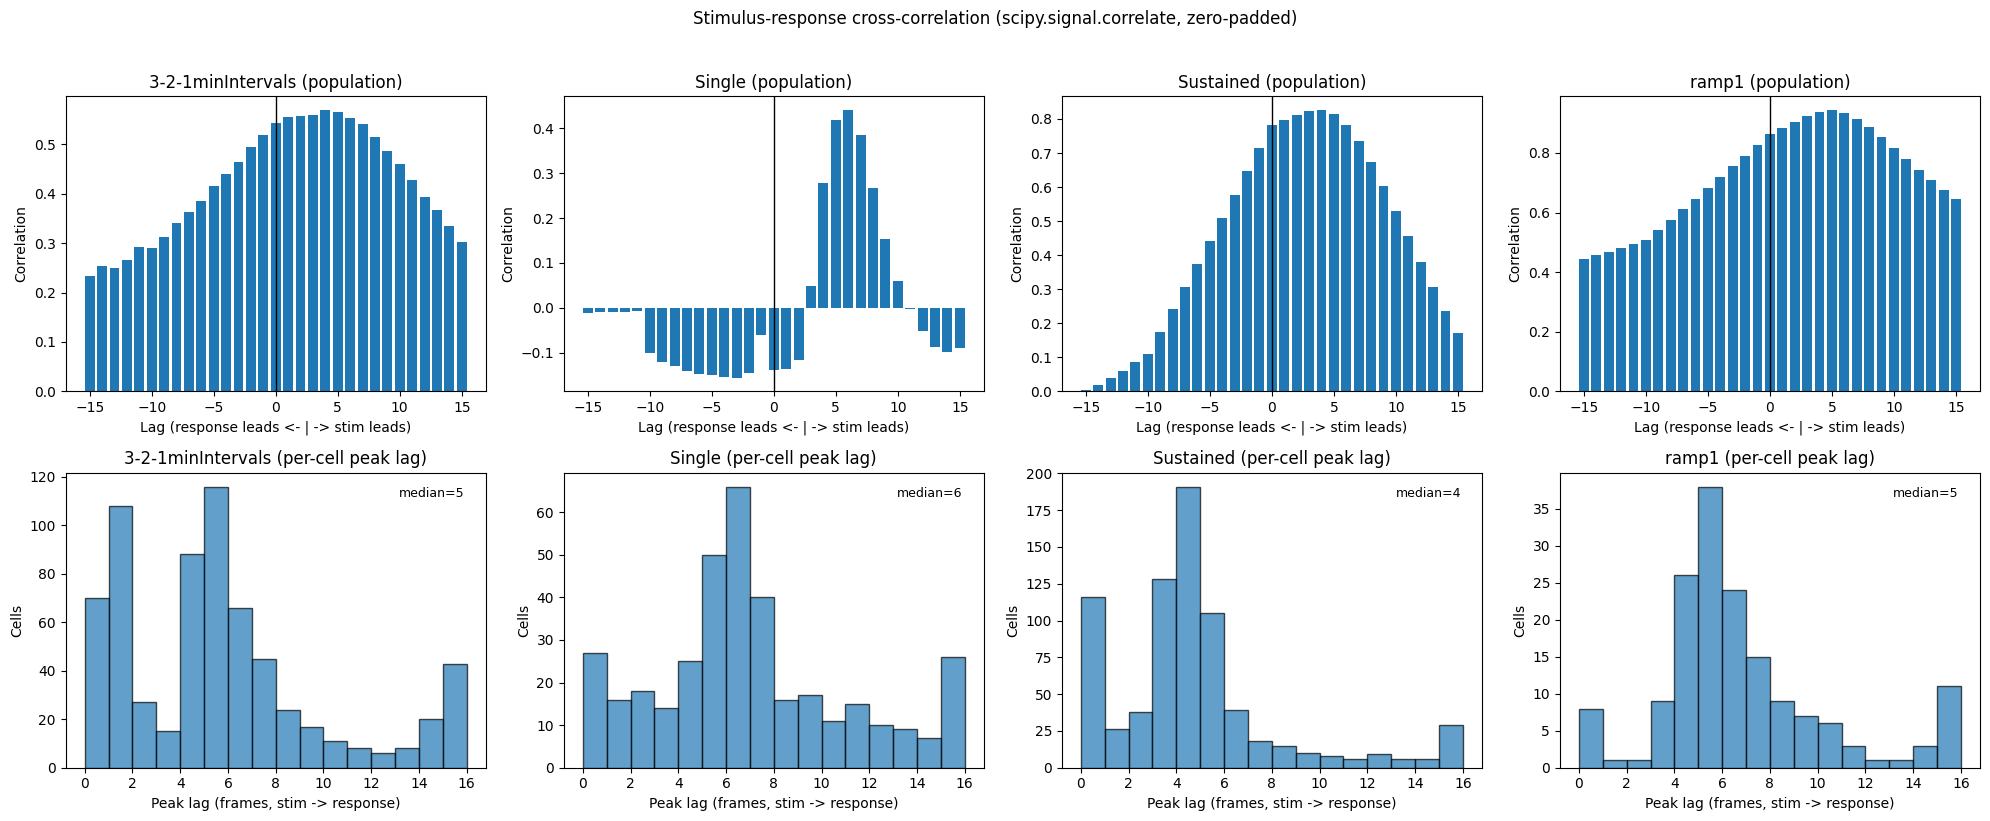

In [16]:
# Cross-correlation using scipy.signal.correlate (zero-padded, not np.roll)
# Population mean version + per-cell peak lag distribution
MAX_LAG = 15

fig, axes = plt.subplots(2, len(patterns), figsize=(5 * len(patterns), 8), squeeze=False)

for col, pat in enumerate(patterns):
    sub = df[df['ramp_pattern_name'] == pat]

    # --- Population-level cross-correlation (top row) ---
    stim_mean = sub.groupby('frame')['stim_exposure'].mean().fillna(0)
    resp_mean = sub.groupby('frame')['cnr_median_norm'].mean()
    common = stim_mean.index.intersection(resp_mean.index)
    s = stim_mean.loc[common].values.astype(float)
    r = resp_mean.loc[common].values.astype(float)
    s = (s - s.mean()) / (s.std() + 1e-9)
    r = (r - r.mean()) / (r.std() + 1e-9)

    full_corr = correlate(r, s, mode='full') / len(s)
    lags_full = np.arange(-len(s) + 1, len(s))
    mask = (lags_full >= -MAX_LAG) & (lags_full <= MAX_LAG)

    ax = axes[0, col]
    ax.bar(lags_full[mask], full_corr[mask], width=0.8)
    ax.axvline(0, color='k', lw=1)
    ax.set_xlabel('Lag (response leads <- | -> stim leads)')
    ax.set_title(f'{pat} (population)')
    ax.set_ylabel('Correlation')

    # --- Per-cell peak lag distribution (bottom row) ---
    ax = axes[1, col]
    uids = sub['uid'].unique()
    peak_lags = []
    for uid in uids:
        cell = sub[sub['uid'] == uid].sort_values('frame')
        cs = cell['stim_exposure'].values.astype(float)
        cr = cell['cnr_median_norm'].values.astype(float)
        if cs.std() < 1e-9 or cr.std() < 1e-9:
            continue
        cs = (cs - cs.mean()) / (cs.std() + 1e-9)
        cr = (cr - cr.mean()) / (cr.std() + 1e-9)
        cc = correlate(cr, cs, mode='full') / len(cs)
        cell_lags = np.arange(-len(cs) + 1, len(cs))
        lag_mask = (cell_lags >= 0) & (cell_lags <= MAX_LAG)
        if lag_mask.any():
            peak_lags.append(cell_lags[lag_mask][np.argmax(cc[lag_mask])])

    ax.hist(peak_lags, bins=range(0, MAX_LAG + 2), edgecolor='black', alpha=0.7)
    ax.set_xlabel('Peak lag (frames, stim -> response)')
    ax.set_ylabel('Cells')
    ax.set_title(f'{pat} (per-cell peak lag)')
    if peak_lags:
        ax.text(0.95, 0.95, f'median={np.median(peak_lags):.0f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Stimulus-response cross-correlation (scipy.signal.correlate, zero-padded)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Engineered feature sanity

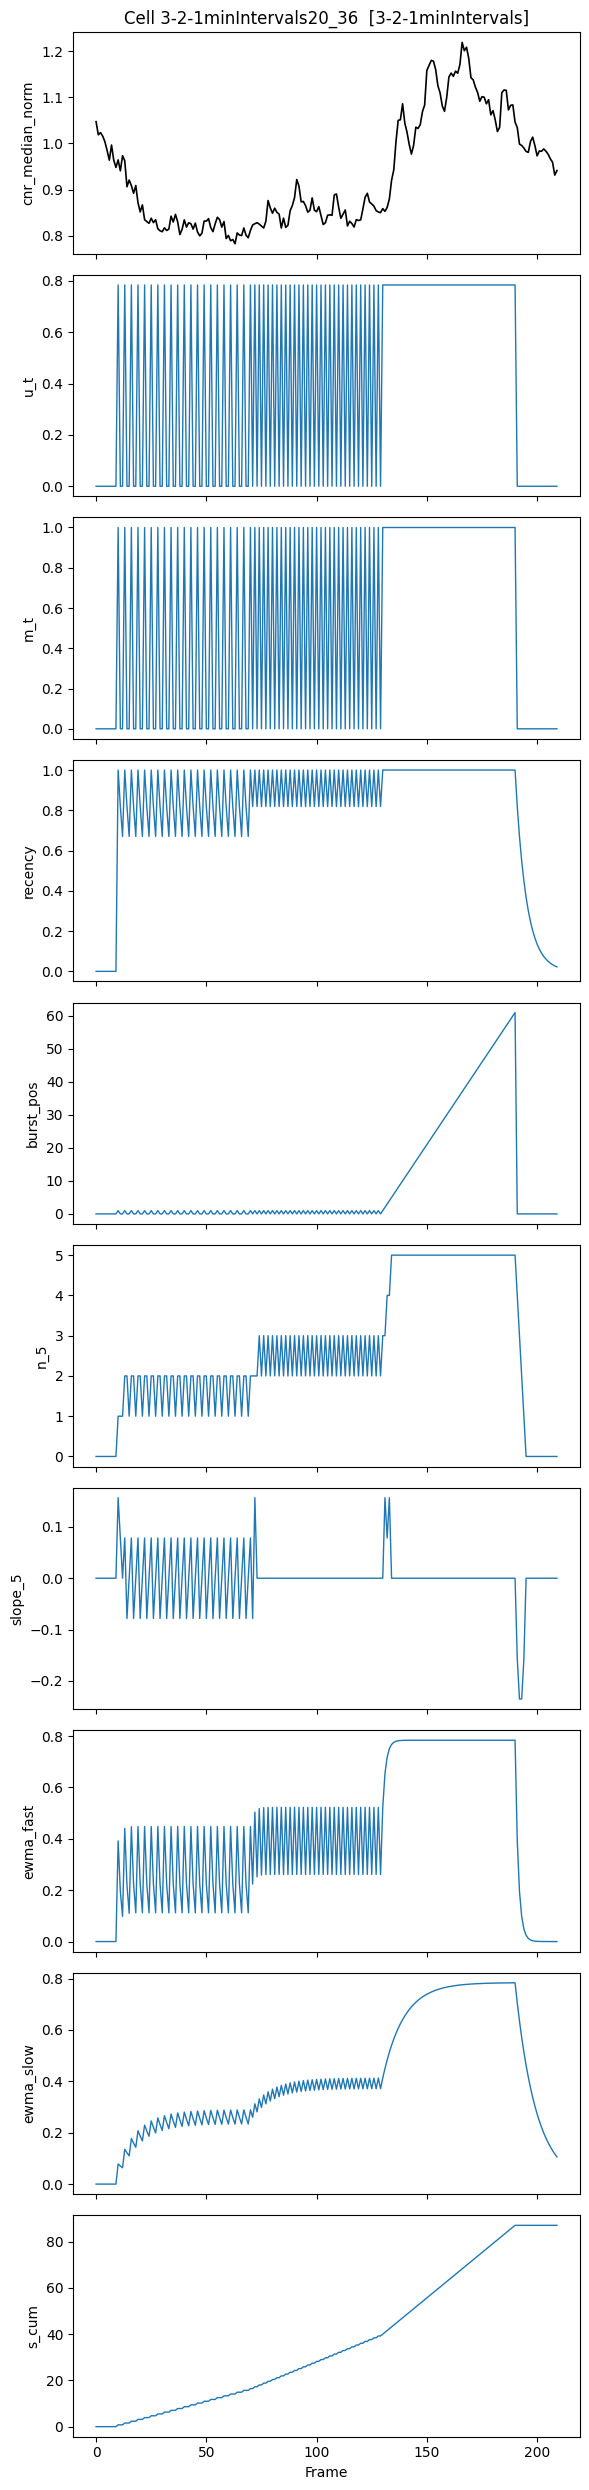

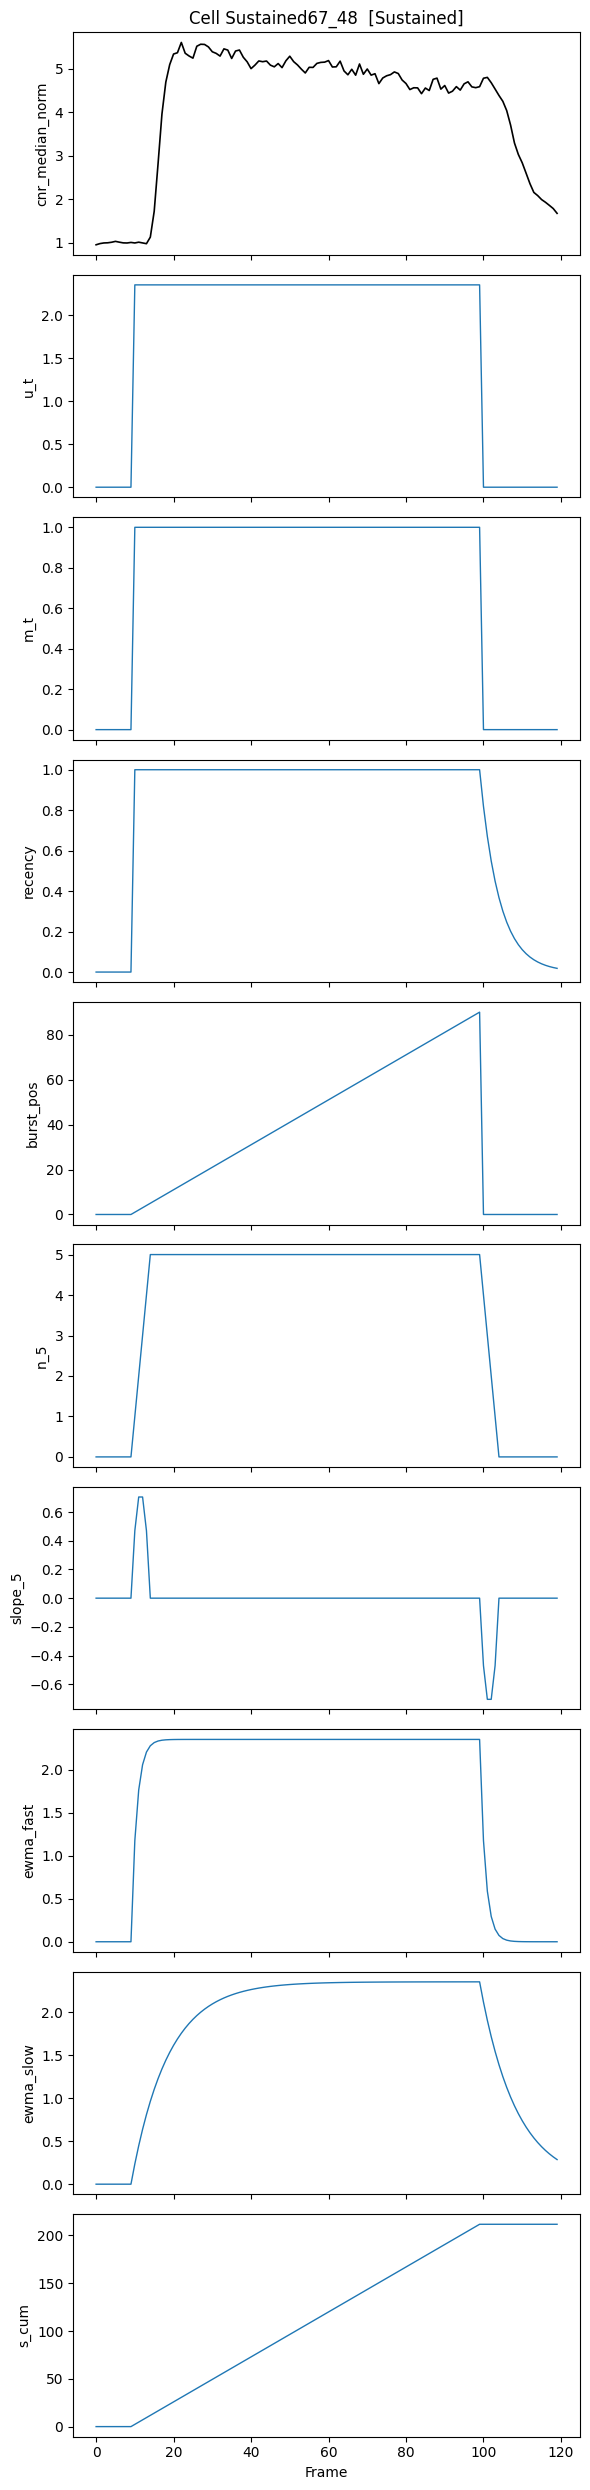

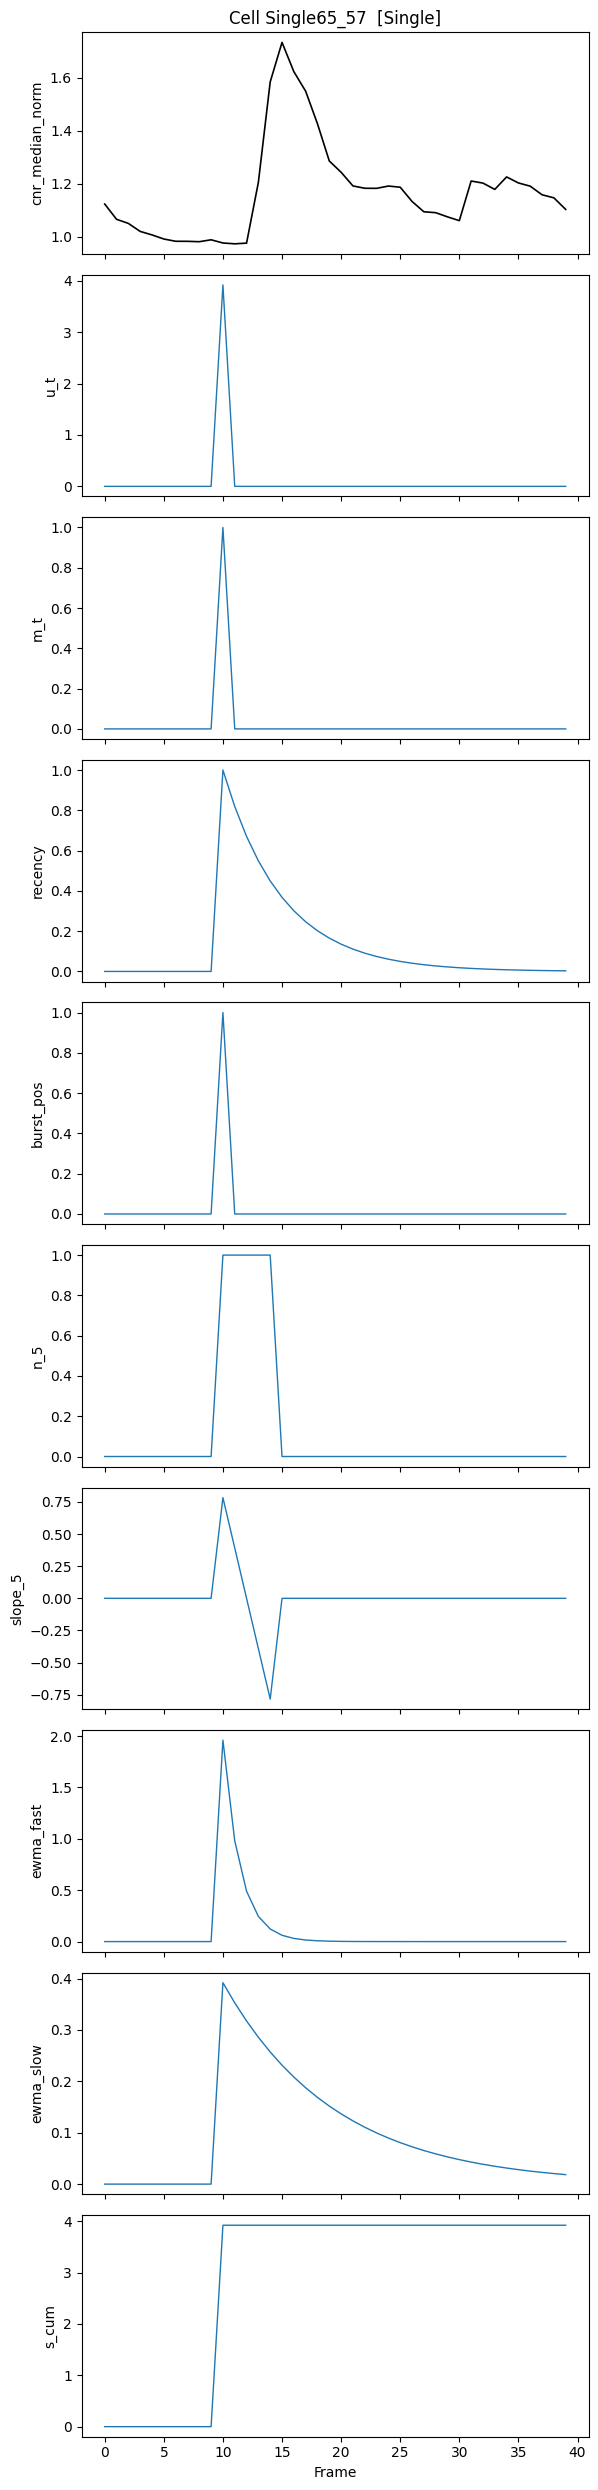

In [17]:
# Plot engineered features for a few representative cells
ENG_COLS = ['u_t', 'm_t', 'recency', 'burst_pos', 'n_5', 'slope_5', 'ewma_fast', 'ewma_slow', 's_cum']
present_eng = [c for c in ENG_COLS if c in df.columns]

np.random.seed(0)
sample_uids = np.random.choice(df['uid'].unique(), size=3, replace=False)

for uid in sample_uids:
    cell = df[df['uid'] == uid].sort_values('frame')
    pat = cell['ramp_pattern_name'].iloc[0]
    n_plots = len(present_eng) + 1  # +1 for response
    fig, axes = plt.subplots(n_plots, 1, figsize=(6, 2.5 * n_plots), sharex=True)

    axes[0].plot(cell['frame'], cell['cnr_median_norm'], color='black', lw=1.2)
    axes[0].set_ylabel('cnr_median_norm')
    axes[0].set_title(f'Cell {uid}  [{pat}]')

    for ax, col in zip(axes[1:], present_eng):
        ax.plot(cell['frame'], cell[col], lw=1)
        ax.set_ylabel(col)

    axes[-1].set_xlabel('Frame')
    plt.tight_layout()
    plt.show()


| Column | Type | Description |
|---|---|---|
| `u_t` | float64 | Raw pulse amplitude (`fluence_mJ_cm2`). Primary input signal. |
| `m_t` | int | Activation indicator: 1 if stimulated, 0 otherwise. Disambiguates rest from zero-amplitude frames. |
| `~~dt_since_pulse~~` | float64 | REPLACED BY `recency` Minutes (frames) since the most recent pulse for this cell. `NaN` before the cell's first pulse. Captures gap dynamics. |
| `recency` | float64 | Saturated recency of a pulse \[0-1] |
| `ewma_fast` | float64 | Exponentially weighted moving average of `u_t` with `alpha=0.5`. Short-term effective stimulation level (equivalent to a discretised first-order ODE with fast decay). |
| `ewma_slow` | float64 | EWMA of `u_t` with `alpha=0.1`. Medium-term accumulation (slow decay). |
| `n_5` | int | Number of pulses (`m_t == 1`) in the last `window_min` frames. Measures burst density. |
| `slope_5` | float64 | OLS slope of `u_t` over the last `window_min` frames. Detects ramp-up / ramp-down patterns. |
| `burst_pos` | int | 1-indexed position within the current consecutive burst of stimulated frames. 0 when the cell is not stimulated. Captures adaptation/facilitation within a burst. |
| `s_cum` | float64 | Cumulative sum of `u_t` up to and including the current frame. Total light exposure history. |


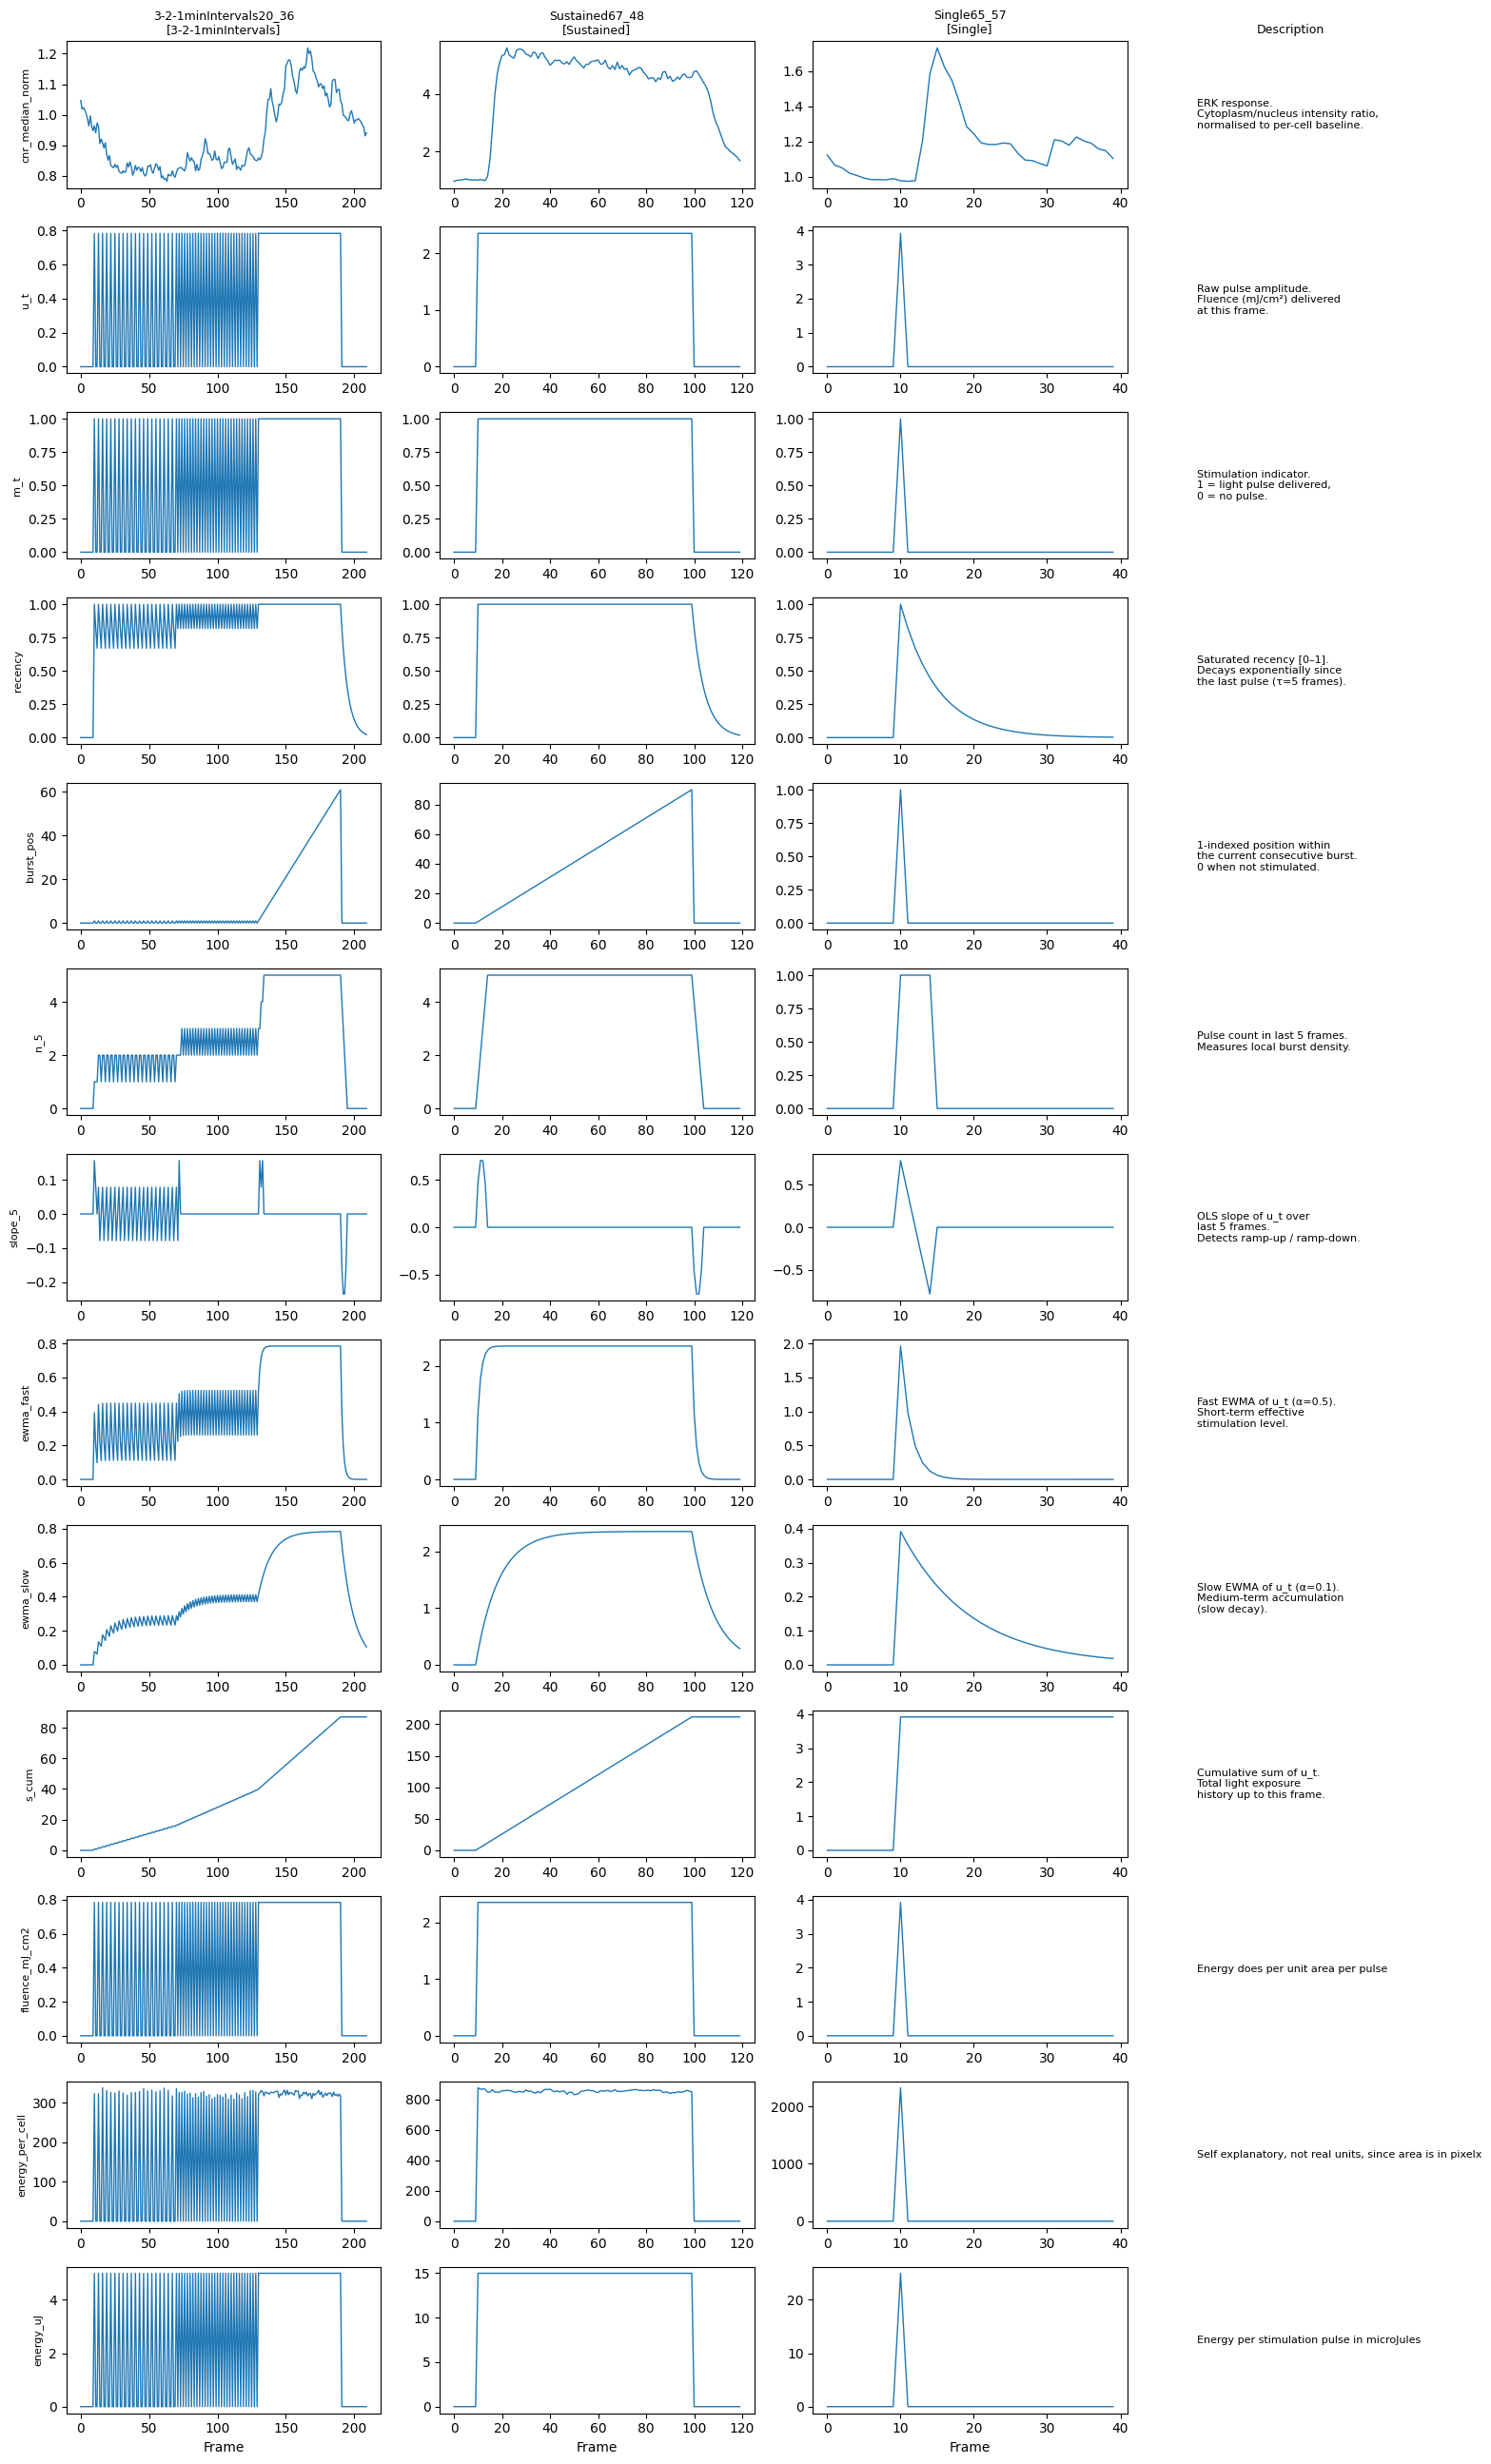

In [18]:
# Plot engineered features for 3 cells: columns = cells, rows = features, 4th col = description
ENG_COLS = ['u_t', 'm_t', 'recency', 'burst_pos', 'n_5', 'slope_5', 'ewma_fast', 'ewma_slow', 's_cum', 'fluence_mJ_cm2', 'energy_per_cell', 'energy_uJ' ]
present_eng = [c for c in ENG_COLS if c in df.columns]
row_labels = ['cnr_median_norm'] + present_eng

DESCRIPTIONS = {
    'cnr_median_norm':   'ERK response.\nCytoplasm/nucleus intensity ratio,\nnormalised to per-cell baseline.',
    'u_t':        'Raw pulse amplitude.\nFluence (mJ/cm²) delivered\nat this frame.',
    'm_t':        'Stimulation indicator.\n1 = light pulse delivered,\n0 = no pulse.',
    'recency':    'Saturated recency [0–1].\nDecays exponentially since\nthe last pulse (τ=5 frames).',
    'burst_pos':  '1-indexed position within\nthe current consecutive burst.\n0 when not stimulated.',
    'n_5':        'Pulse count in last 5 frames.\nMeasures local burst density.',
    'slope_5':    'OLS slope of u_t over\nlast 5 frames.\nDetects ramp-up / ramp-down.',
    'ewma_fast':  'Fast EWMA of u_t (α=0.5).\nShort-term effective\nstimulation level.',
    'ewma_slow':  'Slow EWMA of u_t (α=0.1).\nMedium-term accumulation\n(slow decay).',
    's_cum':      'Cumulative sum of u_t.\nTotal light exposure\nhistory up to this frame.',
    'fluence_mJ_cm2':'Energy does per unit area per pulse',
    'energy_per_cell':'Self explanatory, not real units, since area is in pixelx', 'energy_uJ':'Energy per stimulation pulse in microJules',
}

np.random.seed(0)
sample_uids = np.random.choice(df['uid'].unique(), size=3, replace=False)
cells = [df[df['uid'] == uid].sort_values('frame') for uid in sample_uids]

n_rows = len(row_labels)
n_cols = 4  # 3 cells + 1 description
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 2 * n_rows),
    gridspec_kw={'width_ratios': [3, 3, 3, 2]},
)

for col_idx, (uid, cell) in enumerate(zip(sample_uids, cells)):
    pat = cell['ramp_pattern_name'].iloc[0]
    axes[0, col_idx].set_title(f'{uid}\n[{pat}]', fontsize=9)
    for row_idx, feat in enumerate(row_labels):
        ax = axes[row_idx, col_idx]
        ax.plot(cell['frame'], cell[feat], lw=1)
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel('Frame')

# 4th column: text descriptions
axes[0, 3].set_title('Description', fontsize=9)
for row_idx, feat in enumerate(row_labels):
    ax = axes[row_idx, 3]
    ax.axis('off')
    ax.text(
        0.05, 0.5,
        DESCRIPTIONS.get(feat, ''),
        transform=ax.transAxes,
        fontsize=8,
        va='center', ha='left',
        wrap=True,
    )

plt.tight_layout()
plt.show()

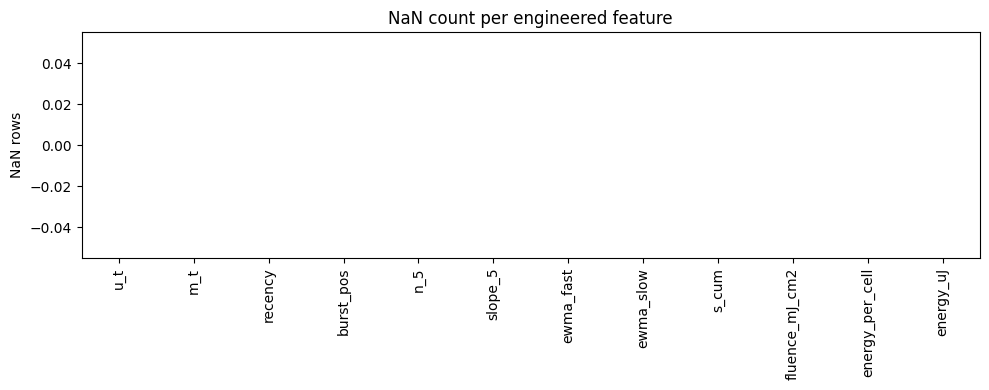

u_t                0
m_t                0
recency            0
burst_pos          0
n_5                0
slope_5            0
ewma_fast          0
ewma_slow          0
s_cum              0
fluence_mJ_cm2     0
energy_per_cell    0
energy_uJ          0
dtype: int64


In [19]:
# NaN locations in engineered features
if present_eng:
    fig, ax = plt.subplots(figsize=(10, 4))
    nan_counts = df[present_eng].isna().sum().sort_values(ascending=False)
    nan_counts.plot(kind='bar', ax=ax)
    ax.set_title('NaN count per engineered feature')
    ax.set_ylabel('NaN rows')
    plt.tight_layout()
    plt.show()
    print(nan_counts)

## 6. Per-cell outlier detection & baseline drift

Scatter plots for outlier identification + baseline drift check to determine
if systematic trends exist that would require detrending before feeding data to the autoencoder.

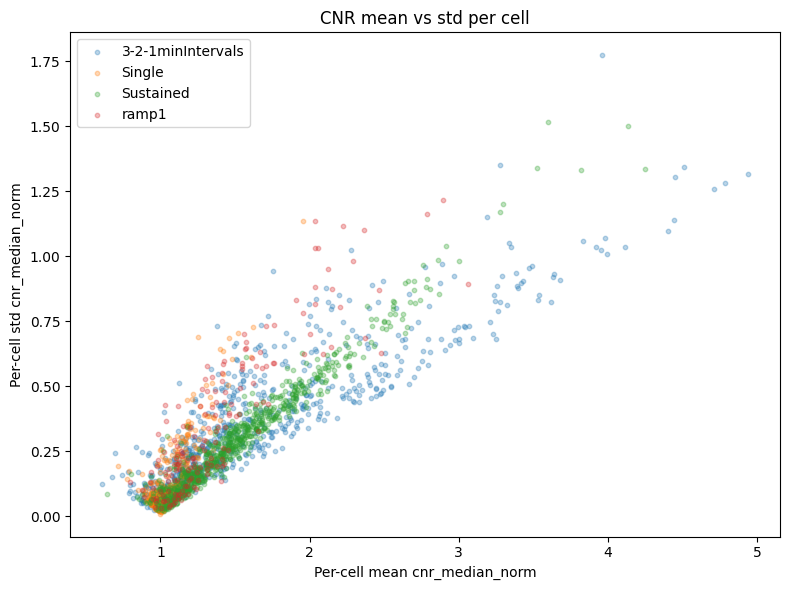

In [20]:
# Per-cell mean CNR vs variance
cell_stats = df.groupby('uid')['cnr_median_norm'].agg(['mean', 'std']).reset_index()
cell_stats = cell_stats.merge(
    df.groupby('uid')['ramp_pattern_name'].first().reset_index(),
    on='uid'
)

fig, ax = plt.subplots(figsize=(8, 6))
for pat in patterns:
    sub = cell_stats[cell_stats['ramp_pattern_name'] == pat]
    ax.scatter(sub['mean'], sub['std'], alpha=0.3, s=10, label=pat)

ax.set_xlabel('Per-cell mean cnr_median_norm')
ax.set_ylabel('Per-cell std cnr_median_norm')
ax.set_title('CNR mean vs std per cell')
ax.legend()
plt.tight_layout()
plt.show()

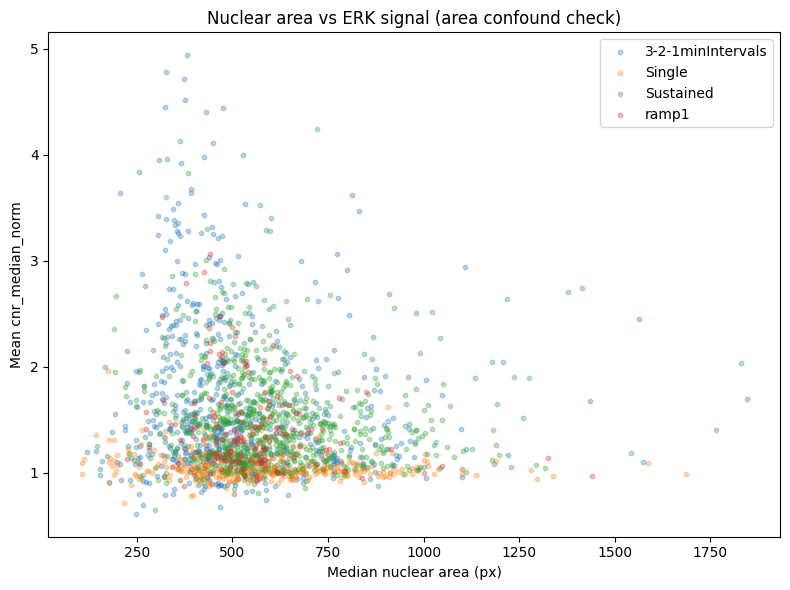

Pearson r (area, mean cnr_median_norm): -0.126


In [21]:
# Nuclear area vs mean CNR — area-confounded signal?
cell_area = df.groupby('uid')['area'].median().reset_index()
cell_area.columns = ['uid', 'median_area']
cell_combined = cell_stats.merge(cell_area, on='uid')

fig, ax = plt.subplots(figsize=(8, 6))
for pat in patterns:
    sub = cell_combined[cell_combined['ramp_pattern_name'] == pat]
    ax.scatter(sub['median_area'], sub['mean'], alpha=0.3, s=10, label=pat)

ax.set_xlabel('Median nuclear area (px)')
ax.set_ylabel('Mean cnr_median_norm')
ax.set_title('Nuclear area vs ERK signal (area confound check)')
ax.legend()
plt.tight_layout()
plt.show()

# Correlation coefficient
r = cell_combined[['median_area', 'mean']].corr().iloc[0, 1]
print(f"Pearson r (area, mean cnr_median_norm): {r:.3f}")

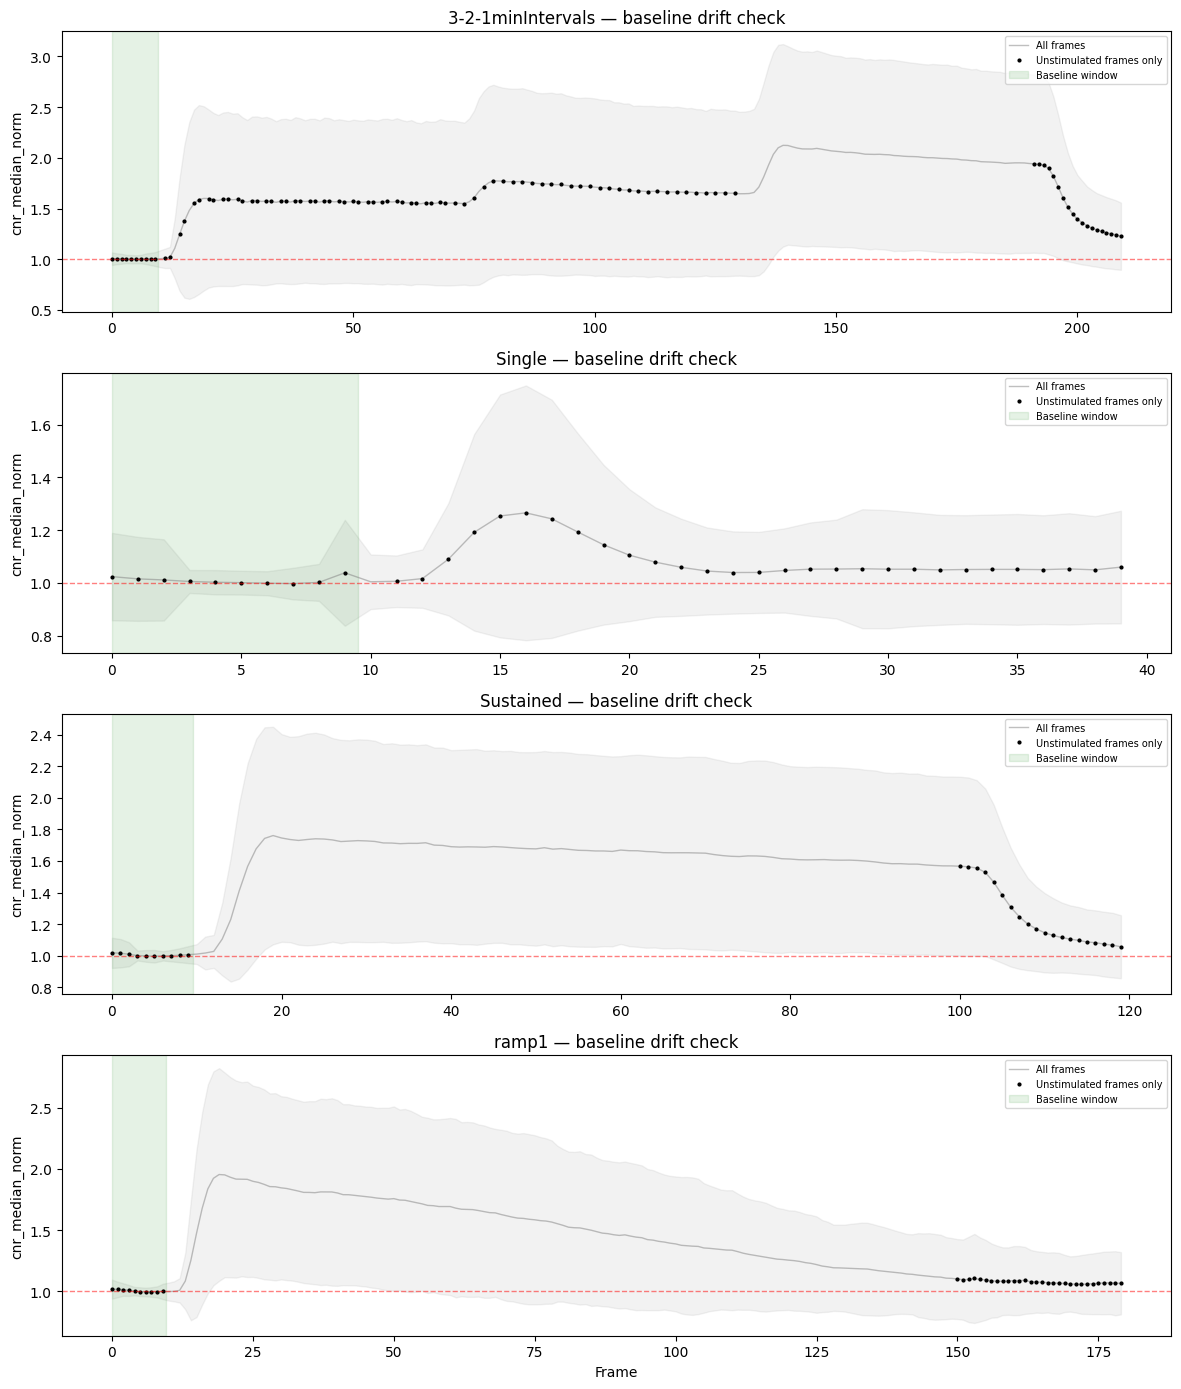

Baseline drift (OLS slope across frames 0-9):
  3-2-1minIntervals: slope = -0.00027 per frame
  Single: slope = -0.00033 per frame
  Sustained: slope = -0.00149 per frame
  ramp1: slope = -0.00274 per frame


In [22]:
# --- Baseline drift check ---
# For each experiment, plot mean cnr_median_norm across all cells at each frame
# in the pre-stim window (frames 0-9). Extend to unstimulated frames throughout
# if inter-pulse gaps exist.

fig, axes = plt.subplots(len(patterns), 1, figsize=(12, 3.5 * len(patterns)), sharex=False)
if len(patterns) == 1:
    axes = [axes]

for ax, pat in zip(axes, patterns):
    sub = df[df['ramp_pattern_name'] == pat]

    # All-frame population mean
    pop = sub.groupby('frame')['cnr_median_norm'].agg(['mean', 'std'])
    ax.fill_between(pop.index, pop['mean'] - pop['std'], pop['mean'] + pop['std'],
                    alpha=0.1, color='grey')
    ax.plot(pop.index, pop['mean'], color='grey', alpha=0.5, lw=1, label='All frames')

    # Unstimulated frames only
    unstim = sub[sub['stim_exposure'] == 0]
    if len(unstim) > 0:
        unstim_pop = unstim.groupby('frame')['cnr_median_norm'].mean()
        ax.plot(unstim_pop.index, unstim_pop.values, 'ko', markersize=2,
                label='Unstimulated frames only')

    # Baseline window
    ax.axvspan(0, BASELINE_FRAMES - 0.5, alpha=0.1, color='green', label='Baseline window')
    ax.axhline(1.0, color='red', lw=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{pat} — baseline drift check')
    ax.set_ylabel('cnr_median_norm')
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Frame')
plt.tight_layout()
plt.show()

# Quantify drift: slope of mean cnr_median_norm in baseline window
print("Baseline drift (OLS slope across frames 0-9):")
for pat in patterns:
    sub = df[(df['ramp_pattern_name'] == pat) & (df['frame'] < BASELINE_FRAMES)]
    means = sub.groupby('frame')['cnr_median_norm'].mean()
    if len(means) >= 2:
        x = means.index.values.astype(float)
        slope = np.polyfit(x, means.values, 1)[0]
        print(f"  {pat}: slope = {slope:.5f} per frame")

## 7. Cross-experiment comparability

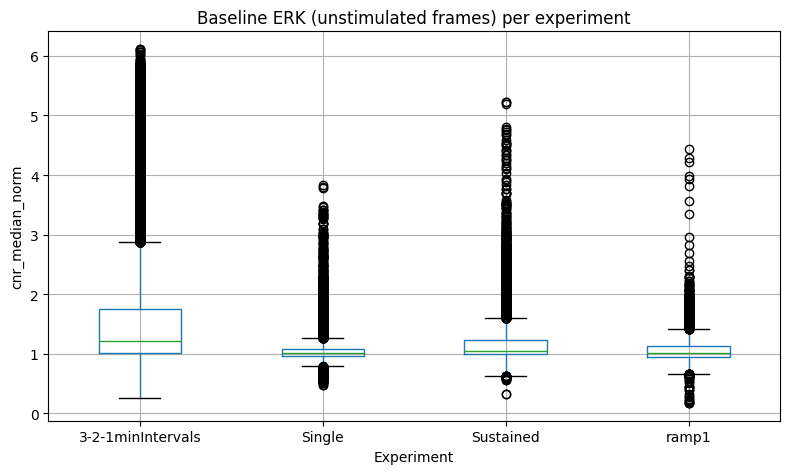

In [23]:
# Baseline cnr_median_norm (pre-stimulation frames) per experiment
pre_stim = df[df['m_t'] == 0] if 'm_t' in df.columns else df[df['stim_exposure'] == 0]

fig, ax = plt.subplots(figsize=(8, 5))
pre_stim.boxplot(column='cnr_median_norm', by='ramp_pattern_name', ax=ax)
ax.set_title('Baseline ERK (unstimulated frames) per experiment')
ax.set_xlabel('Experiment')
ax.set_ylabel('cnr_median_norm')
plt.suptitle('')
plt.tight_layout()
plt.show()

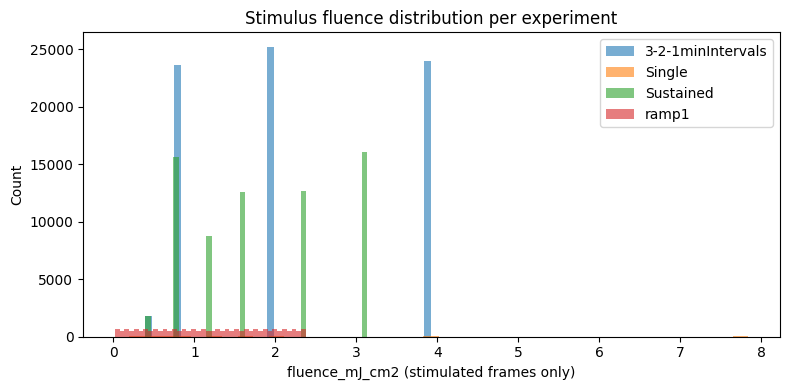

In [24]:
# Fluence distribution per experiment
stim_only = df[df['fluence_mJ_cm2'] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
for pat in patterns:
    vals = stim_only[stim_only['ramp_pattern_name'] == pat]['fluence_mJ_cm2']
    if len(vals):
        ax.hist(vals, bins=40, alpha=0.6, label=pat)
ax.set_xlabel('fluence_mJ_cm2 (stimulated frames only)')
ax.set_ylabel('Count')
ax.set_title('Stimulus fluence distribution per experiment')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Class balance

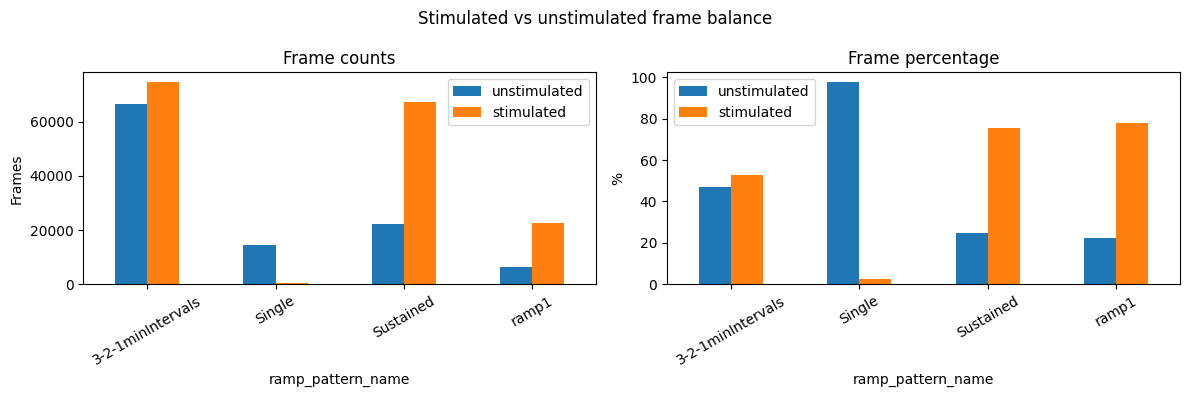

,unstimulated,stimulated
ramp_pattern_name,,
3-2-1minIntervals,47.1,52.9
Single,97.5,2.5
Sustained,24.7,75.3
ramp1,22.2,77.8


In [25]:
# Stimulated vs unstimulated frames per experiment
if 'm_t' in df.columns:
    balance = df.groupby('ramp_pattern_name')['m_t'].value_counts().unstack(fill_value=0)
    balance.columns = ['unstimulated', 'stimulated']
    balance_pct = balance.div(balance.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    balance.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Frame counts')
    axes[0].set_ylabel('Frames')
    axes[0].tick_params(axis='x', rotation=30)

    balance_pct.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Frame percentage')
    axes[1].set_ylabel('%')
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle('Stimulated vs unstimulated frame balance')
    plt.tight_layout()
    plt.show()
    display(balance_pct.round(1))

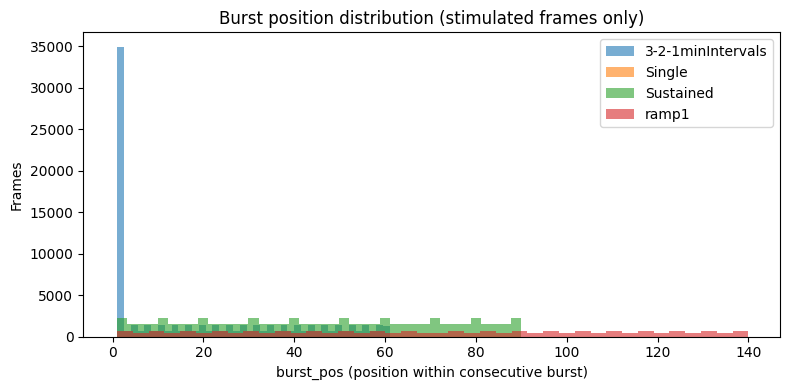

In [26]:
# Distribution of burst_pos values (how common are long bursts?)
if 'burst_pos' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    stim_frames = df[df['burst_pos'] > 0]
    for pat in patterns:
        vals = stim_frames[stim_frames['ramp_pattern_name'] == pat]['burst_pos']
        if len(vals):
            ax.hist(vals, bins=40, alpha=0.6, label=pat)
    ax.set_xlabel('burst_pos (position within consecutive burst)')
    ax.set_ylabel('Frames')
    ax.set_title('Burst position distribution (stimulated frames only)')
    ax.legend()
    plt.tight_layout()
    plt.show()